In [ ]:
# Importing Python libraries
import pickle
import numpy as np
import matplotlib.pyplot as plt
import random
import cv2
import skimage.morphology as morp
import skimage
from skimage.filters import rank
from sklearn.utils import shuffle
import csv
import os
import tensorflow as tf
import pandas as pd
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
from tensorflow.keras.layers import Flatten
from sklearn.metrics import confusion_matrix

Instructions for updating:
non-resource variables are not supported in the long term


In [ ]:
training_file = "/content/train.p"
validation_file= "/content/valid.p"
testing_file = "/content/test.p"

with open(training_file, mode='rb') as f:
    train = pickle.load(f)
with open(validation_file, mode='rb') as f:
    valid = pickle.load(f)
with open(testing_file, mode='rb') as f:
    test = pickle.load(f)

In [ ]:
# Mapping ClassID to traffic sign names
signs = []
with open('signnames.csv', 'r') as csvfile:
    signnames = csv.reader(csvfile, delimiter=',')
    next(signnames,None)
    for row in signnames:
        signs.append(row[1])
    csvfile.close()

In [ ]:
class_file = "signnames.csv"
class_df = pd.read_csv(os.path.join(class_file))
class_df

,ClassId,SignName
0,0,Speed limit (20km/h)
1,1,Speed limit (30km/h)
2,2,Speed limit (50km/h)
3,3,Speed limit (60km/h)
4,4,Speed limit (70km/h)
5,5,Speed limit (80km/h)
6,6,End of speed limit (80km/h)
7,7,Speed limit (100km/h)
8,8,Speed limit (120km/h)
9,9,No passing


The pickled data is a dictionary with 4 key/value pairs:

'features' is a 4D array containing raw pixel data of the traffic sign images, (num examples, width, height, channels).
'labels' is a 1D array containing the label/class id of the traffic sign. The file signnames.csv contains id -> name mappings for each id.
'sizes' is a list containing tuples, (width, height) representing the original width and height the image.
'coords' is a list containing tuples, (x1, y1, x2, y2) representing coordinates of a bounding box around the sign in the image.
The code snippets below will provide a basic summery of the Dataset.

First, we will use numpy provide the number of images in each subset, in addition to the image size, and the number of unique classes.

In [ ]:
X_train, y_train = train['features'], train['labels']
X_valid, y_valid = valid['features'], valid['labels']
X_test, y_test = test['features'], test['labels']

# Number of training examples
n_train = X_train.shape[0]

# Number of testing examples
n_test = X_test.shape[0]

# Number of validation examples.
n_validation = X_valid.shape[0]

# What's the shape of an traffic sign image?
image_shape = X_train[0].shape

# How many unique classes/labels there are in the dataset.
n_classes = len(np.unique(y_train))

print("Number of training examples: ", n_train)
print("Number of testing examples: ", n_test)
print("Number of validation examples: ", n_validation)
print("Image data shape =", image_shape)
print("Number of classes =", n_classes)

Number of training examples:  34799
Number of testing examples:  12630
Number of validation examples:  4410
Image data shape = (32, 32, 3)
Number of classes = 43


In [ ]:
def list_images(dataset, dataset_y, ylabel="", cmap=None):
    """
    Display a list of images in a single figure with matplotlib.
        Parameters:
            images: An np.array compatible with plt.imshow.
            lanel (Default = No label): A string to be used as a label for each image.
            cmap (Default = None): Used to display gray images.
    """
    plt.figure(figsize=(15, 16))
    for i in range(6):
        plt.subplot(1, 6, i+1)
        indx = random.randint(0, len(dataset))
        #Use gray scale color map if there is only one channel
        cmap = 'gray' if len(dataset[indx].shape) == 2 else cmap
        plt.imshow(dataset[indx], cmap = cmap)
        plt.xlabel(signs[dataset_y[indx]])
        plt.ylabel(ylabel)
        plt.xticks([])
        plt.yticks([])
    plt.tight_layout(pad=0, h_pad=0, w_pad=0)
    plt.show()

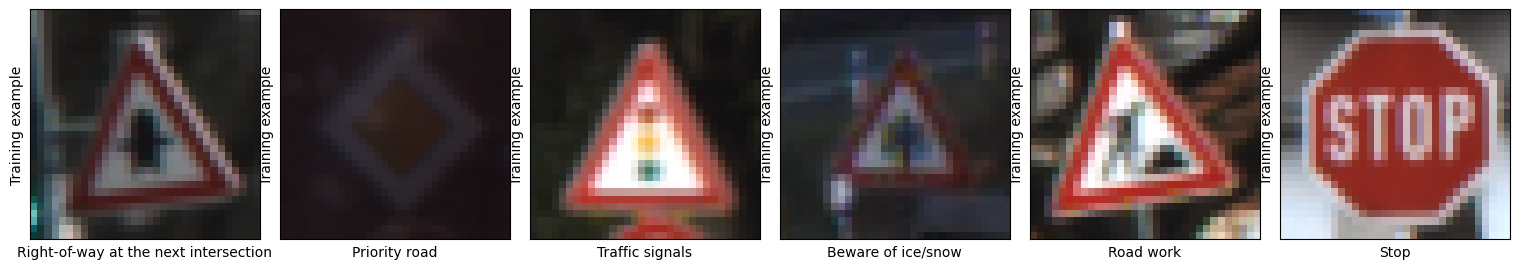

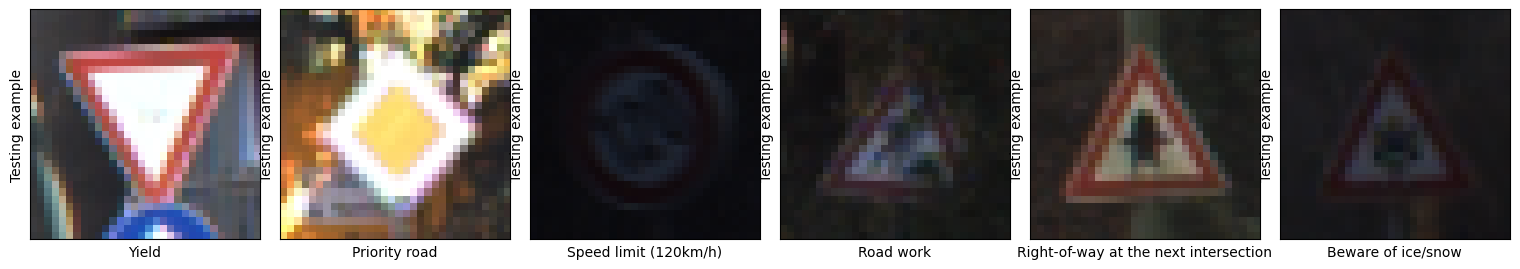

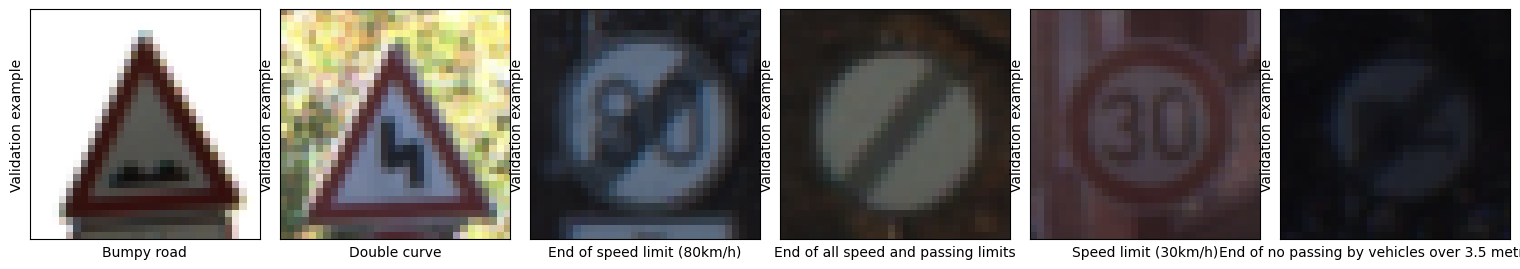

In [ ]:
# Plotting sample examples
list_images(X_train, y_train, "Training example")
list_images(X_test, y_test, "Testing example")
list_images(X_valid, y_valid, "Validation example")

In [ ]:
def histogram_plot(dataset, label):
    """
    Plots a histogram of the input data.
        Parameters:
            dataset: Input data to be plotted as a histogram.
            lanel: A string to be used as a label for the histogram.
    """
    hist, bins = np.histogram(dataset, bins=n_classes)
    width = 0.7 * (bins[1] - bins[0])
    center = (bins[:-1] + bins[1:]) / 2
    plt.bar(center, hist, align='center', width=width)
    plt.xlabel(label)
    plt.ylabel("Image count")
    plt.show()

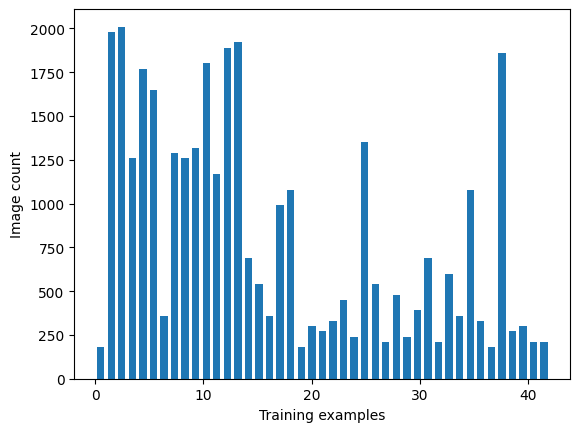

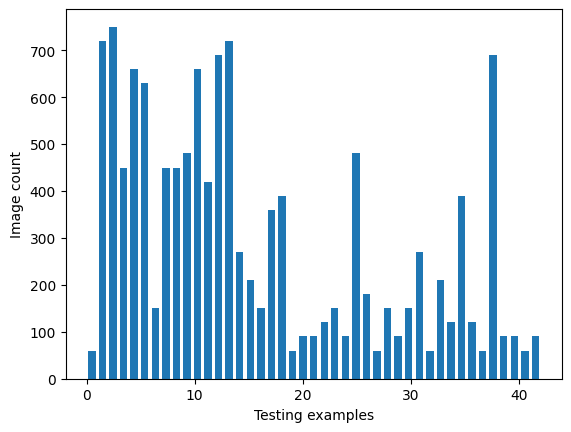

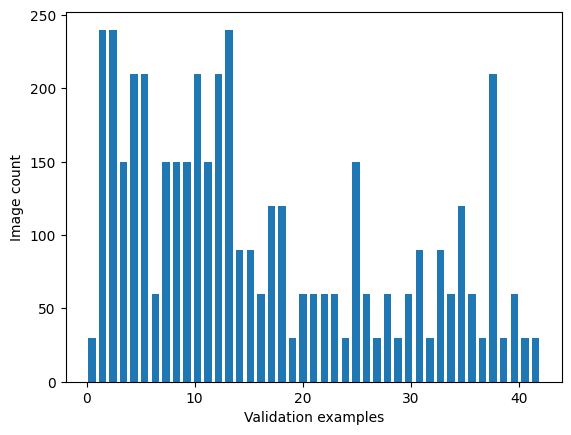

In [ ]:
# Plotting histograms of the count of each sign
histogram_plot(y_train, "Training examples")
histogram_plot(y_test, "Testing examples")
histogram_plot(y_valid, "Validation examples")

Data Preprocessing
In this step, we will apply several preprocessing steps to the input images to achieve the best possible results.

We will use the following preprocessing techniques:

Shuffling.
Grayscaling.
Local Histogram Equalization.
Normalization.
Shuffling: In general, we shuffle the training data to increase randomness and variety in training dataset, in order for the model to be more stable. We will use sklearn to shuffle our data.

In [ ]:
X_train, y_train = shuffle(X_train, y_train)

In [ ]:
def gray_scale(image):
    """
    Convert images to gray scale.
        Parameters:
            image: An np.array compatible with plt.imshow.
    """
    return cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

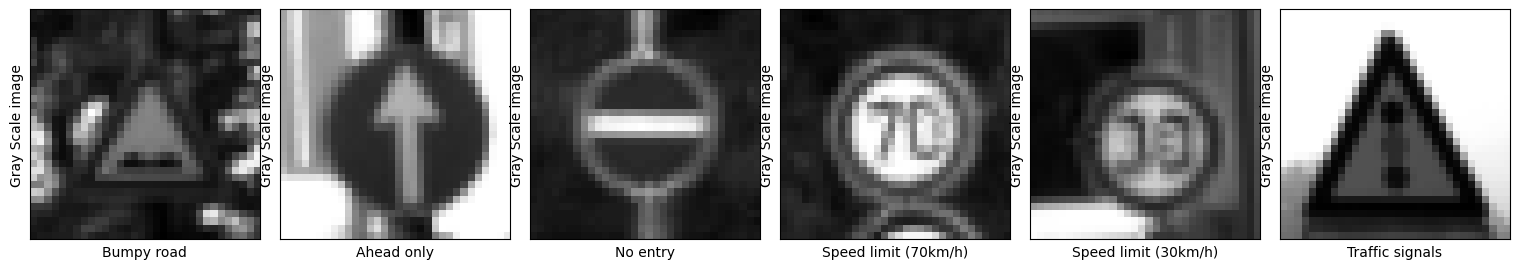

In [ ]:
# Sample images after grayscaling
gray_images = list(map(gray_scale, X_train))
list_images(gray_images, y_train, "Gray Scale image", "gray")

In [ ]:
def local_histo_equalize(image):
    """
    Apply local histogram equalization to grayscale images.
        Parameters:
            image: A grayscale image.
    """
    kernel = morp.disk(30)
    img_local = rank.equalize(image, footprint=kernel)
    return img_local

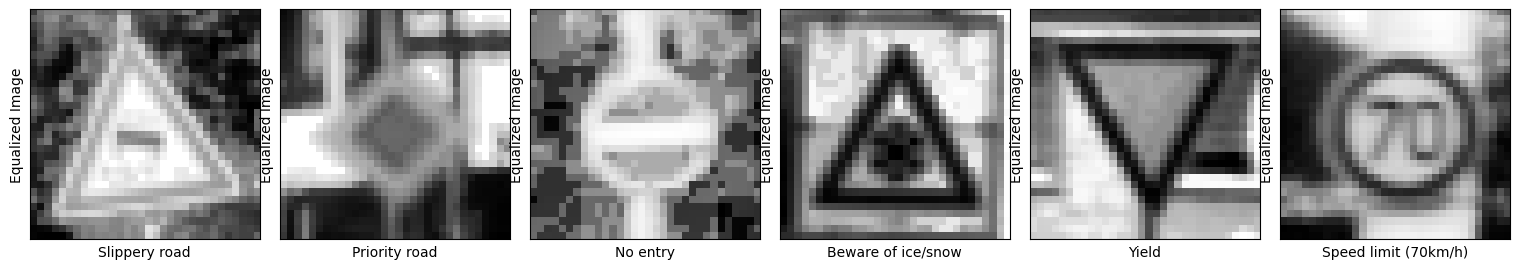

In [ ]:
# Sample images after Local Histogram Equalization
equalized_images = list(map(local_histo_equalize, gray_images))
list_images(equalized_images, y_train, "Equalized Image", "gray")
#skimage.filters.rank.entropy(equalized_images, footprint, out=None, mask=None, shift_x=False, shift_y=False, shift_z=False)

In [ ]:
def image_normalize(image):
    """
    Normalize images to [0, 1] scale.
        Parameters:
            image: An np.array compatible with plt.imshow.
    """
    image = np.divide(image, 255)
    return image

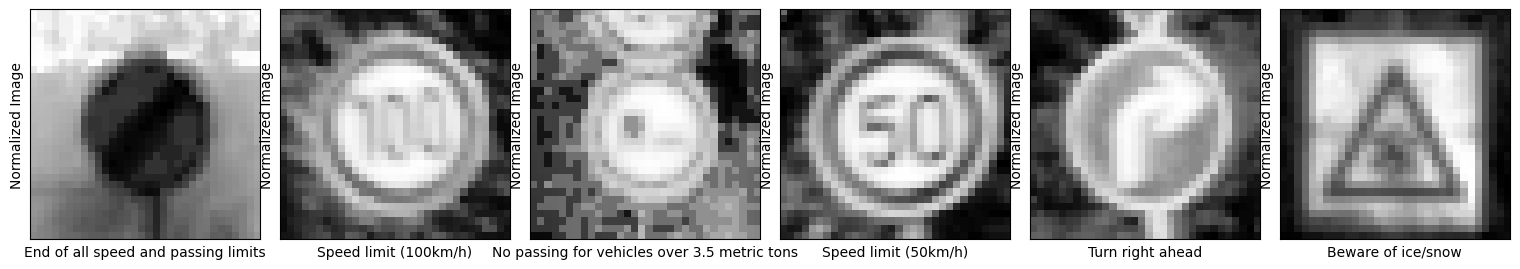

In [ ]:
# Sample images after normalization
n_training = X_train.shape
normalized_images = np.zeros((n_training[0], n_training[1], n_training[2]))
for i, img in enumerate(equalized_images):
    normalized_images[i] = image_normalize(img)
list_images(normalized_images, y_train, "Normalized Image", "gray")
normalized_images = normalized_images[..., None]

In [ ]:
def preprocess(data):
    """
    Applying the preprocessing steps to the input data.
        Parameters:
            data: An np.array compatible with plt.imshow.
    """
    gray_images = list(map(gray_scale, data))
    equalized_images = list(map(local_histo_equalize, gray_images))
    n_training = data.shape
    normalized_images = np.zeros((n_training[0], n_training[1], n_training[2]))
    for i, img in enumerate(equalized_images):
        normalized_images[i] = image_normalize(img)
    normalized_images = normalized_images[..., None]
    return normalized_images

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2],
    shear_range=0.1,
    horizontal_flip=False
)

In [ ]:
class VGGnet:

    def __init__(self, n_out=43, mu=0, sigma=0.1, learning_rate=0.001):
        # Hyperparameters
        self.mu = mu
        self.sigma = sigma

        # Layer 1 (Convolutional): Input = 32x32x1. Output = 32x32x32.
        self.conv1_W = tf.Variable(tf.truncated_normal(shape=(3, 3, 1, 32), mean = self.mu, stddev = self.sigma))
        self.conv1_b = tf.Variable(tf.zeros(32))
        self.conv1   = tf.nn.conv2d(x, self.conv1_W, strides=[1, 1, 1, 1], padding='SAME') + self.conv1_b

        # ReLu Activation.
        self.conv1 = tf.nn.relu(self.conv1)

        # Layer 2 (Convolutional): Input = 32x32x32. Output = 32x32x32.
        self.conv2_W = tf.Variable(tf.truncated_normal(shape=(3, 3, 32, 32), mean = self.mu, stddev = self.sigma))
        self.conv2_b = tf.Variable(tf.zeros(32))
        self.conv2   = tf.nn.conv2d(self.conv1, self.conv2_W, strides=[1, 1, 1, 1], padding='SAME') + self.conv2_b

        # ReLu Activation.
        self.conv2 = tf.nn.relu(self.conv2)

        # Layer 3 (Pooling): Input = 32x32x32. Output = 16x16x32.
        self.conv2 = tf.nn.max_pool(self.conv2, ksize=[1, 2, 2, 1], strides=[1, 2, 2, 1], padding='VALID')
        self.conv2 = tf.nn.dropout(self.conv2, keep_prob_conv)

        # Layer 4 (Convolutional): Input = 16x16x32. Output = 16x16x64.
        self.conv3_W = tf.Variable(tf.truncated_normal(shape=(3, 3, 32, 64), mean = self.mu, stddev = self.sigma))
        self.conv3_b = tf.Variable(tf.zeros(64))
        self.conv3   = tf.nn.conv2d(self.conv2, self.conv3_W, strides=[1, 1, 1, 1], padding='SAME') + self.conv3_b

        # ReLu Activation.
        self.conv3 = tf.nn.relu(self.conv3)

        # Layer 5 (Convolutional): Input = 16x16x64. Output = 16x16x64.
        self.conv4_W = tf.Variable(tf.truncated_normal(shape=(3, 3, 64, 64), mean = self.mu, stddev = self.sigma))
        self.conv4_b = tf.Variable(tf.zeros(64))
        self.conv4   = tf.nn.conv2d(self.conv3, self.conv4_W, strides=[1, 1, 1, 1], padding='SAME') + self.conv4_b

        # ReLu Activation.
        self.conv4 = tf.nn.relu(self.conv4)

        # Layer 6 (Pooling): Input = 16x16x64. Output = 8x8x64.
        self.conv4 = tf.nn.max_pool(self.conv4, ksize=[1, 2, 2, 1], strides=[1, 2, 2, 1], padding='VALID')
        self.conv4 = tf.nn.dropout(self.conv4, keep_prob_conv) # dropout

        # Layer 7 (Convolutional): Input = 8x8x64. Output = 8x8x128.
        self.conv5_W = tf.Variable(tf.truncated_normal(shape=(3, 3, 64, 128), mean = self.mu, stddev = self.sigma))
        self.conv5_b = tf.Variable(tf.zeros(128))
        self.conv5   = tf.nn.conv2d(self.conv4, self.conv5_W, strides=[1, 1, 1, 1], padding='SAME') + self.conv5_b

        # ReLu Activation.
        self.conv5 = tf.nn.relu(self.conv5)

        # Layer 8 (Convolutional): Input = 8x8x128. Output = 8x8x128.
        self.conv6_W = tf.Variable(tf.truncated_normal(shape=(3, 3, 128, 128), mean = self.mu, stddev = self.sigma))
        self.conv6_b = tf.Variable(tf.zeros(128))
        self.conv6   = tf.nn.conv2d(self.conv5, self.conv6_W, strides=[1, 1, 1, 1], padding='SAME') + self.conv6_b

        # ReLu Activation.
        self.conv6 = tf.nn.relu(self.conv6)

        # Layer 9 (Pooling): Input = 8x8x128. Output = 4x4x128.
        self.conv6 = tf.nn.max_pool(self.conv6, ksize=[1, 2, 2, 1], strides=[1, 2, 2, 1], padding='VALID')
        self.conv6 = tf.nn.dropout(self.conv6, keep_prob_conv) # dropout

        # Flatten. Input = 4x4x128. Output = 2048.
        #self.fc0   = tf.keras.layers.Flatten()(self.conv6)
        self.fc0 = tf.reshape(self.conv6, [-1, 4 * 4 * 128])


        # Layer 10 (Fully Connected): Input = 2048. Output = 128.
        self.fc1_W = tf.Variable(tf.truncated_normal(shape=(2048, 128), mean = self.mu, stddev = self.sigma))
        self.fc1_b = tf.Variable(tf.zeros(128))
        self.fc1   = tf.matmul(self.fc0, self.fc1_W) + self.fc1_b

        # ReLu Activation.
        self.fc1    = tf.nn.relu(self.fc1)
        self.fc1    = tf.nn.dropout(self.fc1, keep_prob) # dropout

        # Layer 11 (Fully Connected): Input = 128. Output = 128.
        self.fc2_W  = tf.Variable(tf.truncated_normal(shape=(128, 128), mean = self.mu, stddev = self.sigma))
        self.fc2_b  = tf.Variable(tf.zeros(128))
        self.fc2    = tf.matmul(self.fc1, self.fc2_W) + self.fc2_b

        # ReLu Activation.
        self.fc2    = tf.nn.relu(self.fc2)
        self.fc2    = tf.nn.dropout(self.fc2, keep_prob) # dropout

        # Layer 12 (Fully Connected): Input = 128. Output = n_out.
        self.fc3_W  = tf.Variable(tf.truncated_normal(shape=(128, n_out), mean = self.mu, stddev = self.sigma))
        self.fc3_b  = tf.Variable(tf.zeros(n_out))
        self.logits = tf.matmul(self.fc2, self.fc3_W) + self.fc3_b

        # Training operation
        self.one_hot_y = tf.one_hot(y, n_out)
        self.cross_entropy = tf.nn.softmax_cross_entropy_with_logits_v2(logits=self.logits, labels=self.one_hot_y)
        self.loss_operation = tf.reduce_mean(self.cross_entropy)
        self.optimizer = tf.train.AdamOptimizer(learning_rate = learning_rate)
        self.training_operation = self.optimizer.minimize(self.loss_operation)

        # Accuracy operation
        self.correct_prediction = tf.equal(tf.argmax(self.logits, 1), tf.argmax(self.one_hot_y, 1))
        self.accuracy_operation = tf.reduce_mean(tf.cast(self.correct_prediction, tf.float32))

        # Saving all variables
        self.saver = tf.train.Saver()

    def y_predict(self, X_data, BATCH_SIZE=64):
        num_examples = len(X_data)
        y_pred = np.zeros(num_examples, dtype=np.int32)
        sess = tf.get_default_session()
        for offset in range(0, num_examples, BATCH_SIZE):
            batch_x = X_data[offset:offset+BATCH_SIZE]
            y_pred[offset:offset+BATCH_SIZE] = sess.run(tf.argmax(self.logits, 1),
                               feed_dict={x:batch_x, keep_prob:1, keep_prob_conv:1})
        return y_pred

    def evaluate(self, X_data, y_data, BATCH_SIZE=64):
        num_examples = len(X_data)
        total_accuracy = 0
        sess = tf.get_default_session()
        for offset in range(0, num_examples, BATCH_SIZE):
            batch_x, batch_y = X_data[offset:offset+BATCH_SIZE], y_data[offset:offset+BATCH_SIZE]
            accuracy = sess.run(self.accuracy_operation,
                                feed_dict={x: batch_x, y: batch_y, keep_prob: 1.0, keep_prob_conv: 1.0 })
            total_accuracy += (accuracy * len(batch_x))
        return total_accuracy / num_examples

In [ ]:
keep_prob = tf.compat.v1.placeholder(tf.float32)
keep_prob_conv = tf.compat.v1.placeholder(tf.float32)


In [ ]:
# Validation set preprocessing
X_valid_preprocessed = preprocess(X_valid)


In [ ]:
EPOCHS = 50
BATCH_SIZE = 64
DIR = 'Saved_Models'

In [ ]:
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()

with tf.Session() as sess:
    sess.run(tf.global_variables_initializer())


x = tf.placeholder(tf.float32, (None, 32, 32, 1))
y = tf.placeholder(tf.int32, (None))

Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.


Shape of normalized_images: (34799, 32, 32, 1)
Shape of y_train: (34799,)
Training...

EPOCH 1 : Loss = 3.2223, Validation Accuracy = 39.977%
EPOCH 2 : Loss = 1.7020, Validation Accuracy = 72.381%
EPOCH 3 : Loss = 0.9571, Validation Accuracy = 86.258%
EPOCH 4 : Loss = 0.6241, Validation Accuracy = 90.816%
EPOCH 5 : Loss = 0.4596, Validation Accuracy = 93.923%
EPOCH 6 : Loss = 0.3661, Validation Accuracy = 96.508%
EPOCH 7 : Loss = 0.2924, Validation Accuracy = 95.986%
EPOCH 8 : Loss = 0.2580, Validation Accuracy = 97.098%
EPOCH 9 : Loss = 0.2210, Validation Accuracy = 98.458%
EPOCH 10 : Loss = 0.1947, Validation Accuracy = 98.707%
EPOCH 11 : Loss = 0.1758, Validation Accuracy = 98.639%
EPOCH 12 : Loss = 0.1557, Validation Accuracy = 98.322%
EPOCH 13 : Loss = 0.1430, Validation Accuracy = 98.390%
EPOCH 14 : Loss = 0.1298, Validation Accuracy = 99.048%
EPOCH 15 : Loss = 0.1350, Validation Accuracy = 98.730%
EPOCH 16 : Loss = 0.1162, Validation Accuracy = 97.868%
EPOCH 17 : Loss = 0.1192, 

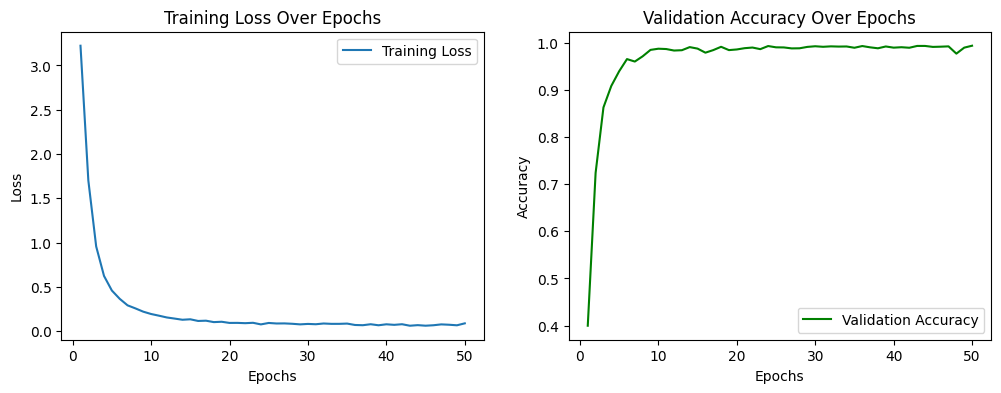

In [ ]:
VGGNet_Model = VGGnet(n_out = n_classes)
model_name = "VGGNet"

# Validation set preprocessing
X_valid_preprocessed = preprocess(X_valid)
one_hot_y_valid = tf.one_hot(y_valid, 43)

# Έλεγχος δεδομένων πριν από την εκπαίδευση
print(f"Shape of normalized_images: {normalized_images.shape}")
print(f"Shape of y_train: {y_train.shape}")

train_losses = []
valid_accuracies = []

with tf.Session() as sess:
    sess.run(tf.global_variables_initializer())
    num_examples = len(y_train)
    print("Training...")
    print()

    for i in range(EPOCHS):
        normalized_images, y_train = shuffle(normalized_images, y_train)
        epoch_loss = 0  # Για αποθήκευση της απώλειας ανά εποχή

        for offset in range(0, num_examples, BATCH_SIZE):
            end = offset + BATCH_SIZE
            batch_x, batch_y = normalized_images[offset:end], y_train[offset:end]

            _, batch_loss = sess.run([VGGNet_Model.training_operation, VGGNet_Model.loss_operation],
                feed_dict={x: batch_x, y: batch_y, keep_prob: 0.5, keep_prob_conv: 0.7})

            epoch_loss += batch_loss

        validation_accuracy = VGGNet_Model.evaluate(X_valid_preprocessed, y_valid)

        train_losses.append(epoch_loss / (num_examples // BATCH_SIZE))  # Μέση απώλεια ανά εποχή
        valid_accuracies.append(validation_accuracy)

        print("EPOCH {} : Loss = {:.4f}, Validation Accuracy = {:.3f}%".format(
            i+1, train_losses[-1], (validation_accuracy*100)))

    VGGNet_Model.saver.save(sess, os.path.join(DIR, model_name))
    print("Model saved")

# Plot training loss and validation accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS+1), train_losses, label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS+1), valid_accuracies, label="Validation Accuracy", color='g')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy Over Epochs")
plt.legend()

plt.show()


# Σύνολο δοκιμής με Γερμανικά σήματα οδικής κυκλοφορίας για Τεστ

In [ ]:
# Test set preprocessing
X_test_preprocessed = preprocess(X_test)

In [ ]:
with tf.Session() as sess:
    VGGNet_Model.saver.restore(sess, os.path.join(DIR, "VGGNet"))
    y_pred = VGGNet_Model.y_predict(X_test_preprocessed)
    test_accuracy = sum(y_test == y_pred)/len(y_test)
    print("Test Accuracy = {:.1f}%".format(test_accuracy*100))

Test Accuracy = 97.7%


# Σύνολο δοκιμής με Ελληνικά σήματα οδικής κυκλοφορίας για Τεστ

In [ ]:
testing_file_gr = "/content/test_gr"

with open(testing_file_gr, mode='rb') as f:
    test_gr = pickle.load(f)

In [ ]:
X_test_gr, y_test_gr = test_gr['data'], test_gr['label']

# Number of testing examples for GRTSRB
n_test_gr = X_test_gr.shape[0]

print("Number of testing examples: ", n_test_gr)

Number of testing examples:  2260


In [ ]:
# Test set preprocessing
X_test_preprocessed_gr = preprocess(X_test_gr)

In [ ]:
with tf.Session() as sess:
    VGGNet_Model.saver.restore(sess, os.path.join(DIR, "VGGNet"))
    y_pred_gr = VGGNet_Model.y_predict(X_test_preprocessed_gr)
    test_accuracy_gr = sum(y_test_gr == y_pred_gr)/len(y_test_gr)
    print("Test Accuracy for Greek Traffic Signs = {:.1f}%".format(test_accuracy_gr*100))

Test Accuracy for Greek Traffic Signs = 68.9%


**Το Test Accuracy με εκπαίδευση του νευρωνικού δικτύου με γερμανικό σύνολο δεδομένων σε Ελληνικά σήματα οδικής κυκλοφορίας απέδωσε 67-73%. Αυτό σημαίνει ότι σε δρόμους Ελληνικού οδικού δικτύου δεν μπορεί το μοντέλο αυτό να δουλέψει αποτελεσματικά.**

# Είσαγωγή Ελληνικών σημάτων οδικής κυκλοφορίας (Gr_train, Gr_valid, Gr_test)

In [ ]:
training_file2 = "/content/Gr_train"
validation_file2= "/content/Gr_valid"
testing_file2 = "/content/Gr_test.p"
#training_file_all = "/content/train_german_greek"

with open(training_file2, mode='rb') as f:
    train2 = pickle.load(f)
with open(validation_file2, mode='rb') as f:
    valid2 = pickle.load(f)
with open(testing_file2, mode='rb') as f:
    test2 = pickle.load(f)
#with open(training_file_all, mode='rb') as f:
    #train_all = pickle.load(f)

In [ ]:
X_train2, y_train2 = train2['data'], train2['label']
X_valid2, y_valid2 = valid2['data'], valid2['label']
X_test2, y_test2 = test2['data'], test2['label']
#X_train_all, y_train_all = train_all['data'], train_all['label']

# Number of training examples
n_train2 = X_train2.shape[0]
# What's the shape of an traffic sign image?
image_shape2 = X_train2[0].shape
# Number of testing examples
n_test2 = X_test2.shape[0]
# Number of validation examples.
n_validation2 = X_valid2.shape[0]
#Number of all training German and Greek
#n_train_all = X_train_all.shape[0]

# How many unique classes/labels there are in the dataset.
n_classes2 = len(np.unique(y_train2))
print("Number of training examples: ", n_train2)
print("Number of testing examples: ", n_test2)
print("Number of validation examples: ", n_validation2)
print("Image data shape =", image_shape2)
print("Number of classes =", n_classes2)
#print("Number of ALL training examples:", n_train_all)

Number of training examples:  1536
Number of testing examples:  506
Number of validation examples:  183
Image data shape = (32, 32, 3)
Number of classes = 43


In [ ]:
X_train_all, y_train_all = shuffle(X_train_all, y_train_all)

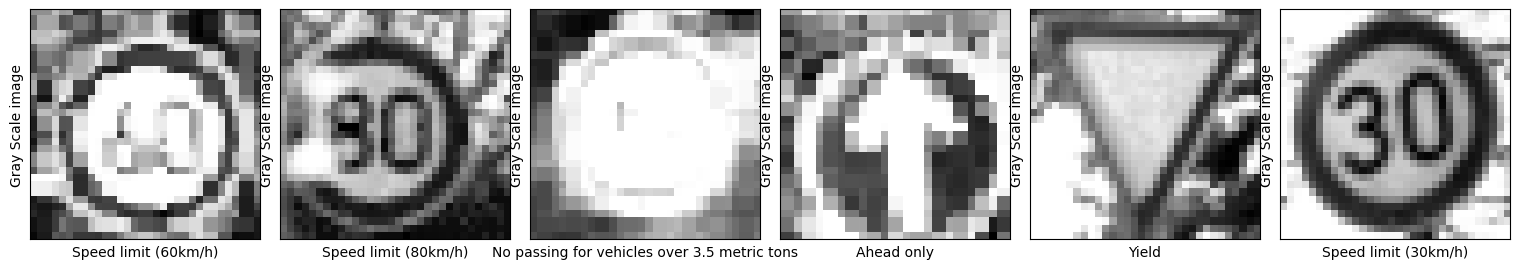

In [ ]:
# Sample images after greyscaling
gray_images = list(map(gray_scale, X_train_all))
list_images(gray_images, y_train_all, "Gray Scale image", "gray")

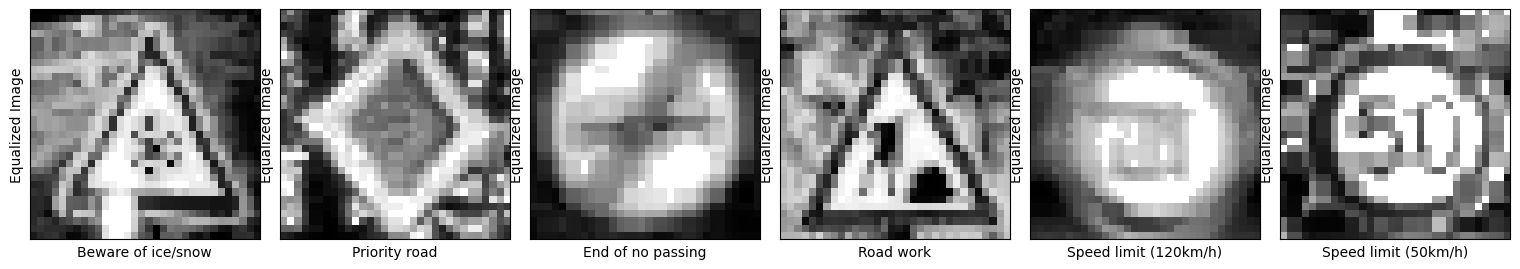

In [ ]:
# Sample images after Local Histogram Equalization
equalized_images = list(map(local_histo_equalize, gray_images))
list_images(equalized_images, y_train_all, "Equalized Image", "gray")
#skimage.filters.rank.entropy(equalized_images, footprint, out=None, mask=None, shift_x=False, shift_y=False, shift_z=False)

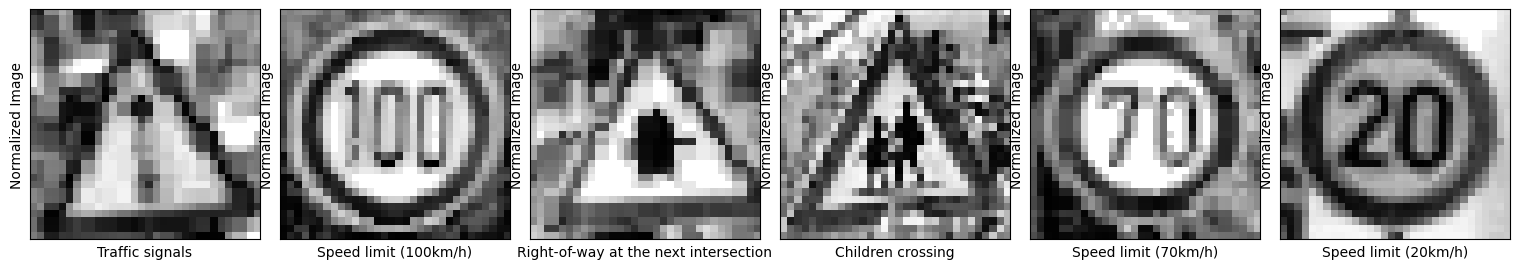

In [ ]:
# Sample images after normalization
n_training = X_train_all.shape
normalized_images = np.zeros((n_training[0], n_training[1], n_training[2]))
for i, img in enumerate(equalized_images):
    normalized_images[i] = image_normalize(img)
list_images(normalized_images, y_train_all, "Normalized Image", "gray")
normalized_images = normalized_images[..., None]

# Εκπαίδευση νευρωνικού δικτύου με mix Γερμανικά και Ελληνικά σήματα οδικής κυκλοφορίας και δοκιμή μόνο με τα Ελληνικά

In [ ]:
# Validation set preprocessing
X_valid_preprocessed = preprocess(X_valid)

In [ ]:
EPOCHS = 30
BATCH_SIZE = 64
DIR = 'Saved_Models'

Training...

EPOCH 1 : Loss = 2.8715, Validation Accuracy = 39.592%
EPOCH 2 : Loss = 1.2532, Validation Accuracy = 67.528%
EPOCH 3 : Loss = 0.7223, Validation Accuracy = 75.193%
EPOCH 4 : Loss = 0.5199, Validation Accuracy = 81.088%
EPOCH 5 : Loss = 0.3843, Validation Accuracy = 83.424%
EPOCH 6 : Loss = 0.3143, Validation Accuracy = 83.583%
EPOCH 7 : Loss = 0.2625, Validation Accuracy = 87.755%
EPOCH 8 : Loss = 0.2328, Validation Accuracy = 87.778%
EPOCH 9 : Loss = 0.2067, Validation Accuracy = 88.435%
EPOCH 10 : Loss = 0.1962, Validation Accuracy = 88.413%
EPOCH 11 : Loss = 0.1836, Validation Accuracy = 87.710%
EPOCH 12 : Loss = 0.1699, Validation Accuracy = 88.662%
EPOCH 13 : Loss = 0.1624, Validation Accuracy = 86.916%
EPOCH 14 : Loss = 0.1489, Validation Accuracy = 88.435%
EPOCH 15 : Loss = 0.1461, Validation Accuracy = 89.025%
EPOCH 16 : Loss = 0.1453, Validation Accuracy = 88.889%
EPOCH 17 : Loss = 0.1360, Validation Accuracy = 89.637%
EPOCH 18 : Loss = 0.1354, Validation Accurac

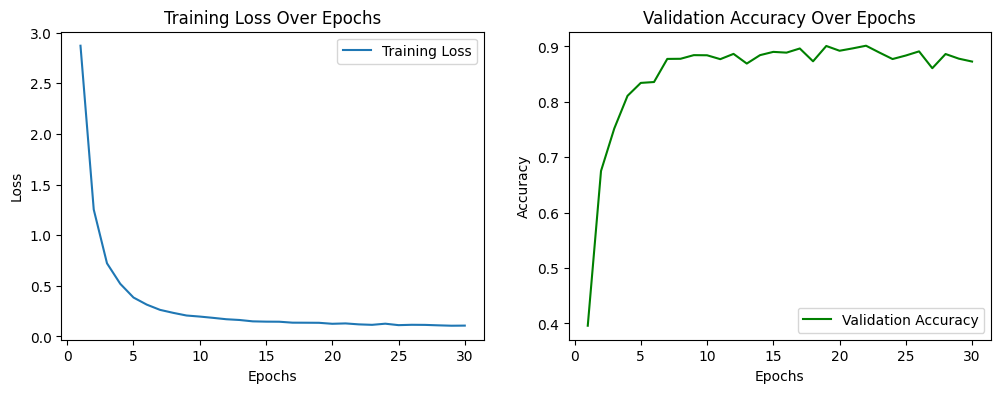

In [ ]:
# Validation set preprocessing
X_valid_preprocessed = preprocess(X_valid)
one_hot_y_valid = tf.one_hot(y_valid, 43)

train_losses = []
valid_accuracies = []

with tf.Session() as sess:
    sess.run(tf.global_variables_initializer())
    num_examples = len(y_train_all)
    print("Training...")
    print()

    for i in range(EPOCHS):
        normalized_images, y_train_all = shuffle(normalized_images, y_train_all)
        epoch_loss = 0  # Για αποθήκευση της απώλειας ανά εποχή

        for offset in range(0, num_examples, BATCH_SIZE):
            end = offset + BATCH_SIZE
            batch_x, batch_y = normalized_images[offset:end], y_train_all[offset:end]

            _, batch_loss = sess.run([VGGNet_Model.training_operation, VGGNet_Model.loss_operation],
                feed_dict={x: batch_x, y: batch_y, keep_prob: 0.5, keep_prob_conv: 0.7})

            epoch_loss += batch_loss

        validation_accuracy = VGGNet_Model.evaluate(X_valid_preprocessed, y_valid)

        train_losses.append(epoch_loss / (num_examples // BATCH_SIZE))  # Μέση απώλεια ανά εποχή
        valid_accuracies.append(validation_accuracy)

        print("EPOCH {} : Loss = {:.4f}, Validation Accuracy = {:.3f}%".format(
            i+1, train_losses[-1], (validation_accuracy*100)))

    VGGNet_Model.saver.save(sess, os.path.join(DIR, model_name))
    print("Model saved")

# Plot training loss and validation accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS+1), train_losses, label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS+1), valid_accuracies, label="Validation Accuracy", color='g')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy Over Epochs")
plt.legend()

plt.show()


In [ ]:
with tf.Session() as sess:
    VGGNet_Model.saver.restore(sess, os.path.join(DIR, "VGGNet"))
    y_pred_gr = VGGNet_Model.y_predict(X_test_preprocessed_gr)
    test_accuracy_gr = sum(y_test_gr == y_pred_gr)/len(y_test_gr)
    print("Test Accuracy for Greek Traffic Signs = {:.1f}%".format(test_accuracy_gr*100))

Test Accuracy for Greek Traffic Signs = 95.0%


**Το test accuracy από 73% ανέβηκε στο 96%**

In [ ]:
import numpy as np

# Μετατρέπουμε τα arrays σε σύνολα για γρηγορότερη αναζήτηση
train_set = set([tuple(x.flatten()) for x in X_train])
test_set = set([tuple(x.flatten()) for x in X_test])

# Βρίσκουμε τα κοινά δείγματα
duplicates = train_set.intersection(test_set)
print(f"Number of duplicate images: {len(duplicates)}")


Number of duplicate images: 0


# Εκπαίδευση δικτύου μόνο με Ελληνικά σήματα οδικής κυκλοφορίας.

In [ ]:
#Ελληνικά σήματα
X_train2, y_train2 = shuffle(X_train2, y_train2)

In [ ]:
def gray_scale(image):
    """
    Convert images to gray scale.
        Parameters:
            image: An np.array compatible with plt.imshow.
    """
    return cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

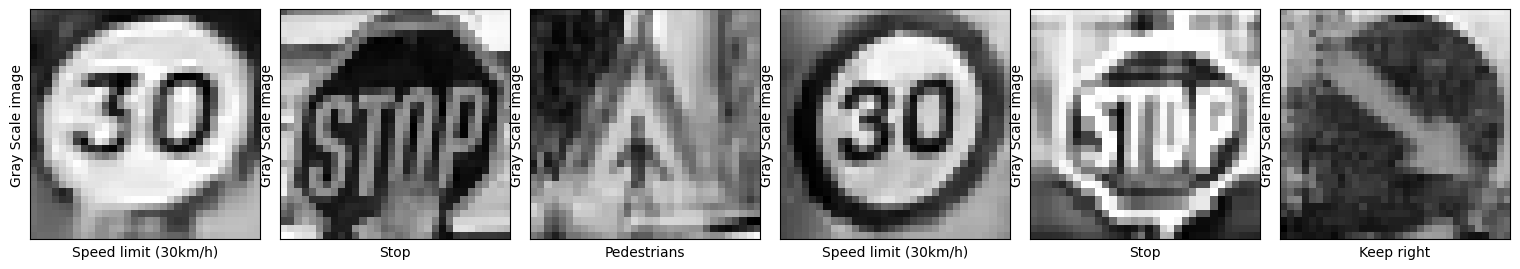

In [ ]:
# Sample images after grayscaling
gray_images = list(map(gray_scale, X_train2))
list_images(gray_images, y_train2, "Gray Scale image", "gray")

In [ ]:
def local_histo_equalize(image):
    """
    Apply local histogram equalization to grayscale images.
        Parameters:
            image: A grayscale image.
    """
    kernel = morp.disk(30)
    img_local = rank.equalize(image, footprint=kernel)
    return img_local

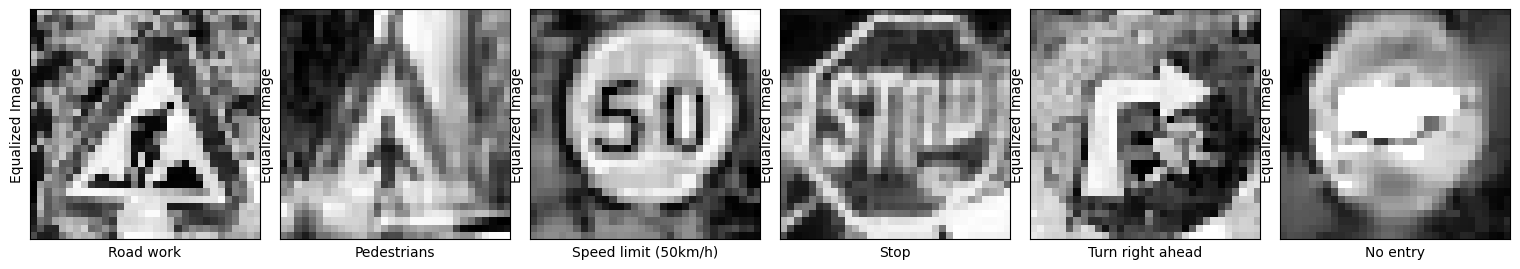

In [ ]:
# Sample images after Local Histogram Equalization
equalized_images = list(map(local_histo_equalize, gray_images))
list_images(equalized_images, y_train2, "Equalized Image", "gray")
#skimage.filters.rank.entropy(equalized_images, footprint, out=None, mask=None, shift_x=False, shift_y=False, shift_z=False)

In [ ]:
def image_normalize(image):
    """
    Normalize images to [0, 1] scale.
        Parameters:
            image: An np.array compatible with plt.imshow.
    """
    image = np.divide(image, 255)
    return image

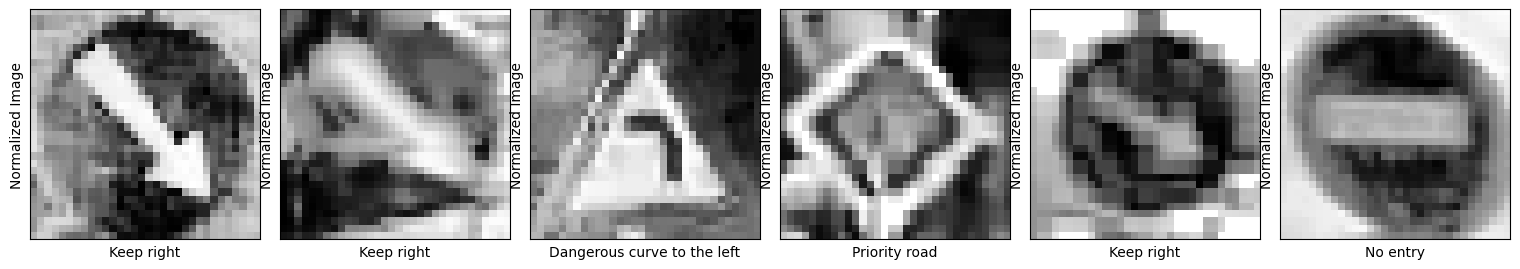

In [ ]:
# Sample images after normalization
n_training = X_train2.shape
normalized_images = np.zeros((n_training[0], n_training[1], n_training[2]))
for i, img in enumerate(equalized_images):
    normalized_images[i] = image_normalize(img)
list_images(normalized_images, y_train2, "Normalized Image", "gray")
normalized_images = normalized_images[..., None]

In [ ]:
# Validation set preprocessing
X_valid_preprocessed = preprocess(X_valid2)

In [ ]:
EPOCHS = 500
BATCH_SIZE = 64
DIR = 'Saved_Models'

VGGNet_Model = VGGnet(n_out = n_classes2)
model_name = "VGGNet"

Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.


Training...

EPOCH 1 : Loss = 4.6102, Validation Accuracy = 7.104%
EPOCH 2 : Loss = 3.3962, Validation Accuracy = 11.475%
EPOCH 3 : Loss = 3.2744, Validation Accuracy = 4.372%
EPOCH 4 : Loss = 3.1208, Validation Accuracy = 7.104%
EPOCH 5 : Loss = 2.9372, Validation Accuracy = 12.022%
EPOCH 6 : Loss = 2.7458, Validation Accuracy = 15.301%
EPOCH 7 : Loss = 2.5646, Validation Accuracy = 20.765%
EPOCH 8 : Loss = 2.4269, Validation Accuracy = 22.404%
EPOCH 9 : Loss = 2.3680, Validation Accuracy = 26.776%
EPOCH 10 : Loss = 2.2129, Validation Accuracy = 30.055%
EPOCH 11 : Loss = 2.1169, Validation Accuracy = 28.962%
EPOCH 12 : Loss = 2.0383, Validation Accuracy = 30.601%
EPOCH 13 : Loss = 1.9692, Validation Accuracy = 33.880%
EPOCH 14 : Loss = 1.8854, Validation Accuracy = 33.880%
EPOCH 15 : Loss = 1.8223, Validation Accuracy = 35.519%
EPOCH 16 : Loss = 1.7864, Validation Accuracy = 34.973%
EPOCH 17 : Loss = 1.7162, Validation Accuracy = 36.066%
EPOCH 18 : Loss = 1.6824, Validation Accuracy =

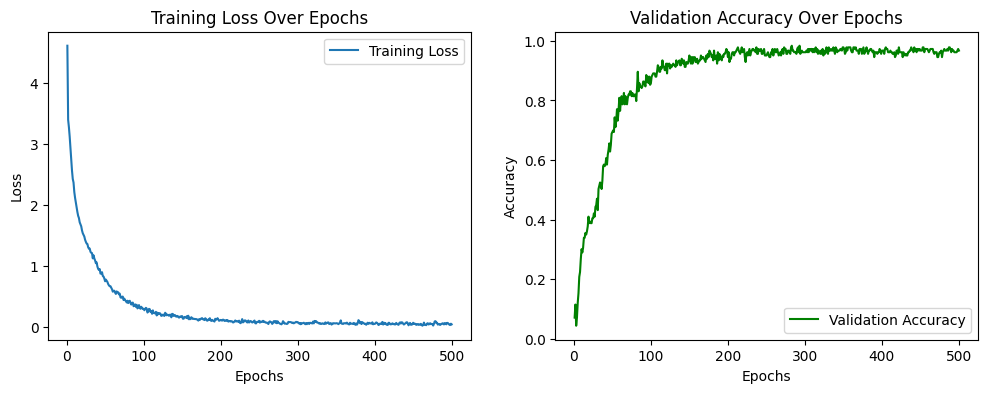

In [ ]:
# Validation set preprocessing
X_valid_preprocessed = preprocess(X_valid2)
one_hot_y_valid = tf.one_hot(y_valid2, 43)

train_losses = []
valid_accuracies = []

with tf.Session() as sess:
    sess.run(tf.global_variables_initializer())
    num_examples = len(y_train2)
    print("Training...")
    print()

    for i in range(EPOCHS):
        normalized_images, y_train2 = shuffle(normalized_images, y_train2)
        epoch_loss = 0  # Για αποθήκευση της απώλειας ανά εποχή

        for offset in range(0, num_examples, BATCH_SIZE):
            end = offset + BATCH_SIZE
            batch_x, batch_y = normalized_images[offset:end], y_train2[offset:end]

            _, batch_loss = sess.run([VGGNet_Model.training_operation, VGGNet_Model.loss_operation],
                feed_dict={x: batch_x, y: batch_y, keep_prob: 0.5, keep_prob_conv: 0.7})

            epoch_loss += batch_loss

        validation_accuracy = VGGNet_Model.evaluate(X_valid_preprocessed, y_valid2)

        train_losses.append(epoch_loss / (num_examples // BATCH_SIZE))  # Μέση απώλεια ανά εποχή
        valid_accuracies.append(validation_accuracy)

        print("EPOCH {} : Loss = {:.4f}, Validation Accuracy = {:.3f}%".format(
            i+1, train_losses[-1], (validation_accuracy*100)))

    VGGNet_Model.saver.save(sess, os.path.join(DIR, model_name))
    print("Model saved")

# Plot training loss and validation accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS+1), train_losses, label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS+1), valid_accuracies, label="Validation Accuracy", color='g')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy Over Epochs")
plt.legend()

plt.show()


In [ ]:
print(train2.keys())
print(valid2.keys())
print(test2.keys())
print(train_all.keys())


dict_keys(['data', 'label'])
dict_keys(['data', 'label'])
dict_keys(['data', 'label'])
dict_keys(['data', 'label'])


In [ ]:
print(X_train2.shape)  # Εκτύπωσε το σχήμα των δεδομένων εκπαίδευσης
print(y_train2.shape)  # Εκτύπωσε το σχήμα των ετικετών εκπαίδευσης
print(X_valid2.shape)  # Εκτύπωσε το σχήμα των δεδομένων επικύρωσης
print(y_valid2.shape)  # Εκτύπωσε το σχήμα των ετικετών επικύρωσης
print(X_test2.shape)   # Εκτύπωσε το σχήμα των δεδομένων δοκιμής
print(y_test2.shape)   # Εκτύπωσε το σχήμα των ετικετών δοκιμής


(1536, 32, 32, 3)
(1536,)
(183, 32, 32, 3)
(183,)
(506, 32, 32, 3)
(506,)


In [ ]:
print(type(X_test2))
print(X_test2.shape if hasattr(X_test2, 'shape') else "No shape attribute")


<class 'numpy.ndarray'>
(506, 32, 32, 3)


In [ ]:
import cv2
import numpy as np

def gray_scale(image):
    """Μετατροπή εικόνας σε grayscale, με έλεγχο εγκυρότητας εικόνας"""
    if isinstance(image, np.ndarray) and image.ndim == 3 and image.shape[2] == 3:
        return cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    else:
        raise ValueError("Η εικόνα πρέπει να είναι σε μορφή NumPy array με 3 κανάλια (RGB).")

# Βεβαιώσου ότι οι εικόνες στο X_test2 είναι np.uint8
X_test2 = X_test2.astype(np.uint8)

# Εφαρμογή grayscale στις εικόνες του test set
for i, img in enumerate(X_test2):
    if img is None or img.shape != (32, 32, 3):
        print(f" Ακατάλληλη εικόνα στο index {i}")
    else:
        # Εφαρμογή της συνάρτησης μετατροπής σε grayscale
        gray_img = gray_scale(img)

In [ ]:
def show_test_images(X, y, class_names, indices=None, n=5):
    """
    Προβάλλει δείγματα από το test set μαζί με τις ετικέτες τους.
    """
    import matplotlib.pyplot as plt

    if indices is None:
        indices = np.random.choice(len(X), n)

    plt.figure(figsize=(15, 3))
    for i, idx in enumerate(indices):
        plt.subplot(1, n, i+1)
        image = X[idx]
        if image.shape[-1] == 1:
            image = image.squeeze()
            plt.imshow(image, cmap='gray')
        else:
            plt.imshow(image)
        plt.title(f"Label: {y[idx]} ({class_names[y[idx]]})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()


In [ ]:
import pandas as pd

df = pd.read_excel("test_greek.xlsx")
print(df.head())

# Πιθανά λάθη:
print("Πλήθος μοναδικών κλάσεων:", df['ClassId'].nunique())
print("Μοναδικά IDs:", df['ClassId'].unique())


    filename  Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId
0  00012.ppm     75      58      12       6      63      48       28
1  00034.ppm    194     130      23      24     172     115       28
2  00064.ppm     77      61      23      20      58      55       14
3  00068.ppm    128     111      22      18     107      90       28
4  00069.ppm    142     103      14      21     118      89       34
Πλήθος μοναδικών κλάσεων: 43
Μοναδικά IDs: [28 14 34 32 27 25 39 18  2 33 22 13 31 38 35 17 15 20 21  4 19 24  8 37
  9 12 23 40 26 42 11 29  1  5  3 16 41 10  7  0 36  6 30]


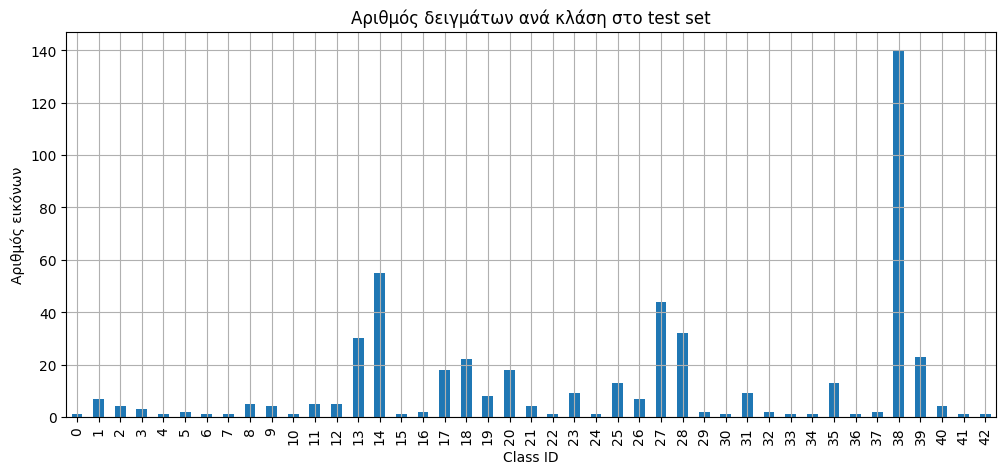

In [ ]:
import matplotlib.pyplot as plt

df['ClassId'].value_counts().sort_index().plot(kind='bar', figsize=(12,5))
plt.title("Αριθμός δειγμάτων ανά κλάση στο test set")
plt.xlabel("Class ID")
plt.ylabel("Αριθμός εικόνων")
plt.grid()
plt.show()


In [ ]:
# Test set preprocessing
X_test_preprocessed2 = preprocess(X_test2)

In [ ]:
with tf.Session() as sess:
    VGGNet_Model.saver.restore(sess, os.path.join(DIR, "VGGNet"))
    y_pred2 = VGGNet_Model.y_predict(X_test_preprocessed2)
    test_accuracy2 = sum(y_test2 == y_pred2)/len(y_test2)
    print("Test Accuracy for Greek Traffic Signs = {:.1f}%".format(test_accuracy2*100))

Test Accuracy for Greek Traffic Signs = 61.9%


Παρατηρούμε ότι στην κλάση 38 υπάρχουν πάρα πολλά δείγματα για δοκιμή σε σχέση με όλες τις υπόλοιπες κλάσεις όπου μπορεί να οφείλετε και η πολύ χαμηλή ακρίβεια στα δεδομένα.

# Δοκιμή αλλαγής του δικτύου για καλύτερα αποτελέσματα στα Ελληνικά σήματα.


In [ ]:
class SimpleVGGnet:
    def __init__(self, n_out=43, mu=0, sigma=0.1, learning_rate=0.001):
        self.mu = mu
        self.sigma = sigma

        # Layer 1: Conv + ReLU + Conv + ReLU + MaxPool
        self.conv1_W = tf.Variable(tf.truncated_normal([3, 3, 1, 32], mean=mu, stddev=sigma))
        self.conv1_b = tf.Variable(tf.zeros(32))
        self.conv1 = tf.nn.relu(tf.nn.conv2d(x, self.conv1_W, [1,1,1,1], padding='SAME') + self.conv1_b)

        self.conv2_W = tf.Variable(tf.truncated_normal([3, 3, 32, 32], mean=mu, stddev=sigma))
        self.conv2_b = tf.Variable(tf.zeros(32))
        self.conv2 = tf.nn.relu(tf.nn.conv2d(self.conv1, self.conv2_W, [1,1,1,1], padding='SAME') + self.conv2_b)

        self.pool1 = tf.nn.max_pool(self.conv2, [1,2,2,1], [1,2,2,1], padding='VALID')
        self.pool1 = tf.nn.dropout(self.pool1, keep_prob_conv)

        # Layer 2: Conv + ReLU + MaxPool
        self.conv3_W = tf.Variable(tf.truncated_normal([3, 3, 32, 64], mean=mu, stddev=sigma))
        self.conv3_b = tf.Variable(tf.zeros(64))
        self.conv3 = tf.nn.relu(tf.nn.conv2d(self.pool1, self.conv3_W, [1,1,1,1], padding='SAME') + self.conv3_b)

        self.pool2 = tf.nn.max_pool(self.conv3, [1,2,2,1], [1,2,2,1], padding='VALID')
        self.pool2 = tf.nn.dropout(self.pool2, keep_prob_conv)

        # Flatten
        self.fc0 = tf.reshape(self.pool2, [-1, 8 * 8 * 64])

        # Fully Connected Layer 1
        self.fc1_W = tf.Variable(tf.truncated_normal([8*8*64, 64], mean=mu, stddev=sigma))
        self.fc1_b = tf.Variable(tf.zeros(64))
        self.fc1 = tf.nn.relu(tf.matmul(self.fc0, self.fc1_W) + self.fc1_b)
        self.fc1 = tf.nn.dropout(self.fc1, keep_prob)

        # Output Layer
        self.fc2_W = tf.Variable(tf.truncated_normal([64, n_out], mean=mu, stddev=sigma))
        self.fc2_b = tf.Variable(tf.zeros(n_out))
        self.logits = tf.matmul(self.fc1, self.fc2_W) + self.fc2_b

        # Loss & Optimizer
        self.one_hot_y = tf.one_hot(y, n_out)
        self.cross_entropy = tf.nn.softmax_cross_entropy_with_logits_v2(logits=self.logits, labels=self.one_hot_y)
        self.loss_operation = tf.reduce_mean(self.cross_entropy)
        self.optimizer = tf.train.AdamOptimizer(learning_rate=learning_rate)
        self.training_operation = self.optimizer.minimize(self.loss_operation)

        # Accuracy
        self.correct_prediction = tf.equal(tf.argmax(self.logits, 1), tf.argmax(self.one_hot_y, 1))
        self.accuracy_operation = tf.reduce_mean(tf.cast(self.correct_prediction, tf.float32))

        self.saver = tf.train.Saver()

    def evaluate(self, X_data, y_data, BATCH_SIZE=64):
        num_examples = len(X_data)
        total_accuracy = 0
        sess = tf.get_default_session()
        for offset in range(0, num_examples, BATCH_SIZE):
            batch_x, batch_y = X_data[offset:offset+BATCH_SIZE], y_data[offset:offset+BATCH_SIZE]
            accuracy = sess.run(self.accuracy_operation, feed_dict={x: batch_x, y: batch_y, keep_prob: 1.0, keep_prob_conv: 1.0})
            total_accuracy += (accuracy * len(batch_x))
        return total_accuracy / num_examples


In [ ]:
EPOCHS = 500
BATCH_SIZE = 64
DIR = 'Saved_Models'

VGGNet_Model = SimpleVGGnet(n_out = n_classes2)
model_name = "VGGNet"

Training...

EPOCH 1 : Loss = 3.6331, Validation Accuracy = 13.661%
EPOCH 2 : Loss = 3.1878, Validation Accuracy = 16.940%
EPOCH 3 : Loss = 2.7954, Validation Accuracy = 24.590%
EPOCH 4 : Loss = 2.4283, Validation Accuracy = 28.962%
EPOCH 5 : Loss = 2.1923, Validation Accuracy = 30.055%
EPOCH 6 : Loss = 2.0319, Validation Accuracy = 32.787%
EPOCH 7 : Loss = 1.9365, Validation Accuracy = 34.973%
EPOCH 8 : Loss = 1.8227, Validation Accuracy = 37.158%
EPOCH 9 : Loss = 1.7455, Validation Accuracy = 38.251%
EPOCH 10 : Loss = 1.6290, Validation Accuracy = 41.530%
EPOCH 11 : Loss = 1.5665, Validation Accuracy = 45.355%
EPOCH 12 : Loss = 1.5236, Validation Accuracy = 42.623%
EPOCH 13 : Loss = 1.4215, Validation Accuracy = 49.180%
EPOCH 14 : Loss = 1.3554, Validation Accuracy = 51.366%
EPOCH 15 : Loss = 1.3394, Validation Accuracy = 50.273%
EPOCH 16 : Loss = 1.2720, Validation Accuracy = 48.087%
EPOCH 17 : Loss = 1.2053, Validation Accuracy = 54.098%
EPOCH 18 : Loss = 1.1710, Validation Accurac

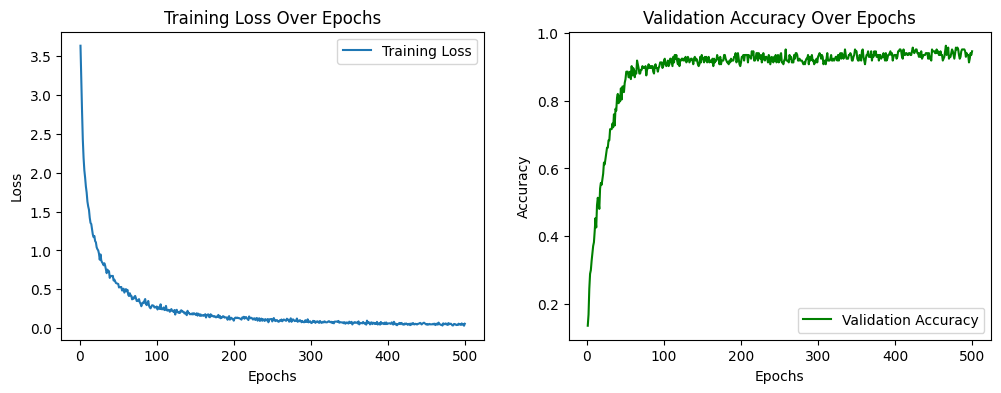

In [ ]:
# Validation set preprocessing
X_valid_preprocessed = preprocess(X_valid2)
one_hot_y_valid = tf.one_hot(y_valid2, 43)

train_losses = []
valid_accuracies = []

with tf.Session() as sess:
    sess.run(tf.global_variables_initializer())
    num_examples = len(y_train2)
    print("Training...")
    print()

    for i in range(EPOCHS):
        normalized_images, y_train2 = shuffle(normalized_images, y_train2)
        epoch_loss = 0  # Για αποθήκευση της απώλειας ανά εποχή

        for offset in range(0, num_examples, BATCH_SIZE):
            end = offset + BATCH_SIZE
            batch_x, batch_y = normalized_images[offset:end], y_train2[offset:end]

            _, batch_loss = sess.run([VGGNet_Model.training_operation, VGGNet_Model.loss_operation],
                feed_dict={x: batch_x, y: batch_y, keep_prob: 0.5, keep_prob_conv: 0.7})

            epoch_loss += batch_loss

        validation_accuracy = VGGNet_Model.evaluate(X_valid_preprocessed, y_valid2)

        train_losses.append(epoch_loss / (num_examples // BATCH_SIZE))  # Μέση απώλεια ανά εποχή
        valid_accuracies.append(validation_accuracy)

        print("EPOCH {} : Loss = {:.4f}, Validation Accuracy = {:.3f}%".format(
            i+1, train_losses[-1], (validation_accuracy*100)))

    VGGNet_Model.saver.save(sess, os.path.join(DIR, model_name))
    print("Model saved")

# Plot training loss and validation accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS+1), train_losses, label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS+1), valid_accuracies, label="Validation Accuracy", color='g')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy Over Epochs")
plt.legend()

plt.show()

In [ ]:
with tf.Session() as sess:
    VGGNet_Model.saver.restore(sess, os.path.join(DIR, "VGGNet"))
    y_pred2 = VGGNet_Model.y_predict(X_test_preprocessed2)
    test_accuracy2 = sum(y_test2 == y_pred2)/len(y_test2)
    print("Test Accuracy for Greek Traffic Signs = {:.1f}%".format(test_accuracy2*100))

Test Accuracy for Greek Traffic Signs = 60.5%


# Δοκιμή με 5χ5 φίλτρα


In [ ]:
class VGGnet:

    def __init__(self, n_out=43, mu=0, sigma=0.1, learning_rate=0.001):
        self.mu = mu
        self.sigma = sigma

        # Layer 1: Conv 5x5 - Input = 32x32x1 → Output = 32x32x16
        self.conv1_W = tf.Variable(tf.truncated_normal(shape=(5, 5, 1, 16), mean=self.mu, stddev=self.sigma))
        self.conv1_b = tf.Variable(tf.zeros(16))
        self.conv1 = tf.nn.conv2d(x, self.conv1_W, strides=[1, 1, 1, 1], padding='SAME') + self.conv1_b
        self.conv1 = tf.nn.relu(self.conv1)

        # Layer 2: MaxPool → Output = 16x16x16
        self.conv1 = tf.nn.max_pool(self.conv1, ksize=[1,2,2,1], strides=[1,2,2,1], padding='VALID')
        self.conv1 = tf.nn.dropout(self.conv1, keep_prob_conv)

        # Layer 3: Conv 5x5 → 16x16x32
        self.conv2_W = tf.Variable(tf.truncated_normal(shape=(5, 5, 16, 32), mean=self.mu, stddev=self.sigma))
        self.conv2_b = tf.Variable(tf.zeros(32))
        self.conv2 = tf.nn.conv2d(self.conv1, self.conv2_W, strides=[1,1,1,1], padding='SAME') + self.conv2_b
        self.conv2 = tf.nn.relu(self.conv2)

        # Layer 4: MaxPool → Output = 8x8x32
        self.conv2 = tf.nn.max_pool(self.conv2, ksize=[1,2,2,1], strides=[1,2,2,1], padding='VALID')
        self.conv2 = tf.nn.dropout(self.conv2, keep_prob_conv)

        # Layer 5: Conv 3x3 → 8x8x64
        self.conv3_W = tf.Variable(tf.truncated_normal(shape=(3, 3, 32, 64), mean=self.mu, stddev=self.sigma))
        self.conv3_b = tf.Variable(tf.zeros(64))
        self.conv3 = tf.nn.conv2d(self.conv2, self.conv3_W, strides=[1,1,1,1], padding='SAME') + self.conv3_b
        self.conv3 = tf.nn.relu(self.conv3)

        # Layer 6: MaxPool → Output = 4x4x64
        self.conv3 = tf.nn.max_pool(self.conv3, ksize=[1,2,2,1], strides=[1,2,2,1], padding='VALID')
        self.conv3 = tf.nn.dropout(self.conv3, keep_prob_conv)

        # Flatten → 4x4x64 = 1024
        self.fc0 = tf.reshape(self.conv3, [-1, 4*4*64])

        # Fully Connected Layer 1: 1024 → 128
        self.fc1_W = tf.Variable(tf.truncated_normal(shape=(1024, 128), mean=self.mu, stddev=self.sigma))
        self.fc1_b = tf.Variable(tf.zeros(128))
        self.fc1 = tf.matmul(self.fc0, self.fc1_W) + self.fc1_b
        self.fc1 = tf.nn.relu(self.fc1)
        self.fc1 = tf.nn.dropout(self.fc1, keep_prob)

        # Fully Connected Layer 2: 128 → n_out
        self.fc2_W = tf.Variable(tf.truncated_normal(shape=(128, n_out), mean=self.mu, stddev=self.sigma))
        self.fc2_b = tf.Variable(tf.zeros(n_out))
        self.logits = tf.matmul(self.fc1, self.fc2_W) + self.fc2_b

        # Loss + Optimizer
        self.one_hot_y = tf.one_hot(y, n_out)
        self.cross_entropy = tf.nn.softmax_cross_entropy_with_logits_v2(logits=self.logits, labels=self.one_hot_y)
        self.loss_operation = tf.reduce_mean(self.cross_entropy)
        self.optimizer = tf.train.AdamOptimizer(learning_rate=learning_rate)
        self.training_operation = self.optimizer.minimize(self.loss_operation)

        # Accuracy
        self.correct_prediction = tf.equal(tf.argmax(self.logits, 1), tf.argmax(self.one_hot_y, 1))
        self.accuracy_operation = tf.reduce_mean(tf.cast(self.correct_prediction, tf.float32))

        self.saver = tf.train.Saver()

    def evaluate(self, X_data, y_data, BATCH_SIZE=64):
        num_examples = len(X_data)
        total_accuracy = 0
        sess = tf.get_default_session()
        for offset in range(0, num_examples, BATCH_SIZE):
            batch_x, batch_y = X_data[offset:offset+BATCH_SIZE], y_data[offset:offset+BATCH_SIZE]
            accuracy = sess.run(self.accuracy_operation, feed_dict={x: batch_x, y: batch_y, keep_prob: 1.0, keep_prob_conv: 1.0})
            total_accuracy += (accuracy * len(batch_x))
        return total_accuracy / num_examples

    def y_predict(self, X_data, BATCH_SIZE=64):
        num_examples = len(X_data)
        y_pred = np.zeros(num_examples, dtype=np.int32)
        sess = tf.get_default_session()
        for offset in range(0, num_examples, BATCH_SIZE):
            batch_x = X_data[offset:offset+BATCH_SIZE]
            y_pred[offset:offset+BATCH_SIZE] = sess.run(tf.argmax(self.logits, 1),
                               feed_dict={x:batch_x, keep_prob:1, keep_prob_conv:1})
        return y_pred

In [ ]:
VGGNet_Model = VGGnet(n_out = n_classes2)
model_name = "VGGNet"

Training...

EPOCH 1 : Loss = 3.9441, Validation Accuracy = 7.104%
EPOCH 2 : Loss = 3.2593, Validation Accuracy = 12.568%
EPOCH 3 : Loss = 3.1568, Validation Accuracy = 9.290%
EPOCH 4 : Loss = 3.0196, Validation Accuracy = 17.486%
EPOCH 5 : Loss = 2.7831, Validation Accuracy = 25.683%
EPOCH 6 : Loss = 2.5269, Validation Accuracy = 27.869%
EPOCH 7 : Loss = 2.2937, Validation Accuracy = 34.426%
EPOCH 8 : Loss = 2.1253, Validation Accuracy = 34.426%
EPOCH 9 : Loss = 2.0172, Validation Accuracy = 37.158%
EPOCH 10 : Loss = 1.8711, Validation Accuracy = 39.344%
EPOCH 11 : Loss = 1.7871, Validation Accuracy = 39.344%
EPOCH 12 : Loss = 1.7038, Validation Accuracy = 40.984%
EPOCH 13 : Loss = 1.6262, Validation Accuracy = 40.984%
EPOCH 14 : Loss = 1.5350, Validation Accuracy = 41.530%
EPOCH 15 : Loss = 1.4739, Validation Accuracy = 45.355%
EPOCH 16 : Loss = 1.4090, Validation Accuracy = 46.995%
EPOCH 17 : Loss = 1.3581, Validation Accuracy = 49.180%
EPOCH 18 : Loss = 1.3361, Validation Accuracy 

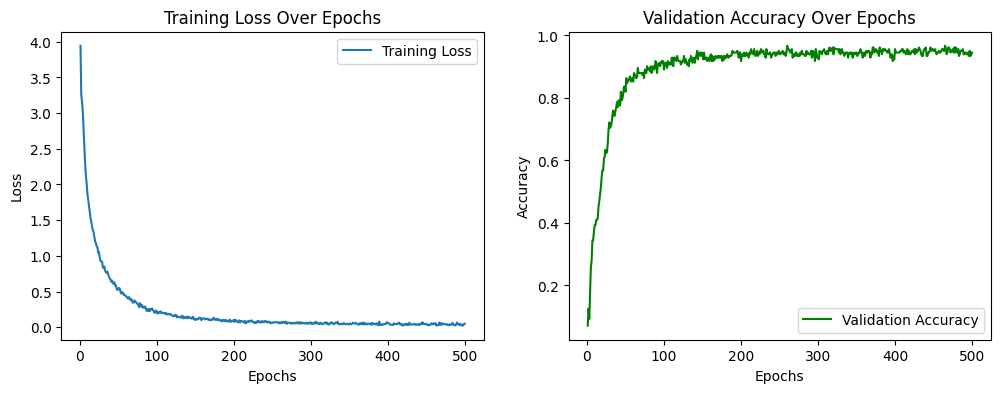

In [ ]:
# Validation set preprocessing
X_valid_preprocessed = preprocess(X_valid2)
one_hot_y_valid = tf.one_hot(y_valid2, 43)

train_losses = []
valid_accuracies = []

with tf.Session() as sess:
    sess.run(tf.global_variables_initializer())
    num_examples = len(y_train2)
    print("Training...")
    print()

    for i in range(EPOCHS):
        normalized_images, y_train2 = shuffle(normalized_images, y_train2)
        epoch_loss = 0  # Για αποθήκευση της απώλειας ανά εποχή

        for offset in range(0, num_examples, BATCH_SIZE):
            end = offset + BATCH_SIZE
            batch_x, batch_y = normalized_images[offset:end], y_train2[offset:end]

            _, batch_loss = sess.run([VGGNet_Model.training_operation, VGGNet_Model.loss_operation],
                feed_dict={x: batch_x, y: batch_y, keep_prob: 0.5, keep_prob_conv: 0.7})

            epoch_loss += batch_loss

        validation_accuracy = VGGNet_Model.evaluate(X_valid_preprocessed, y_valid2)

        train_losses.append(epoch_loss / (num_examples // BATCH_SIZE))  # Μέση απώλεια ανά εποχή
        valid_accuracies.append(validation_accuracy)

        print("EPOCH {} : Loss = {:.4f}, Validation Accuracy = {:.3f}%".format(
            i+1, train_losses[-1], (validation_accuracy*100)))

    VGGNet_Model.saver.save(sess, os.path.join(DIR, model_name))
    print("Model saved")

# Plot training loss and validation accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS+1), train_losses, label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS+1), valid_accuracies, label="Validation Accuracy", color='g')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy Over Epochs")
plt.legend()

plt.show()

In [ ]:
with tf.Session() as sess:
    VGGNet_Model.saver.restore(sess, os.path.join(DIR, "VGGNet"))
    y_pred2 = VGGNet_Model.y_predict(X_test_preprocessed2)
    test_accuracy2 = sum(y_test2 == y_pred2)/len(y_test2)
    print("Test Accuracy for Greek Traffic Signs = {:.1f}%".format(test_accuracy2*100))

Test Accuracy for Greek Traffic Signs = 52.8%


# Δοκιμή του ίδιο δικτύου με 1000 εποχές

In [ ]:
EPOCHS = 1000
BATCH_SIZE = 64
DIR = 'Saved_Models'

Training...

EPOCH 1 : Loss = 3.7586, Validation Accuracy = 4.372%
EPOCH 2 : Loss = 3.2408, Validation Accuracy = 10.383%
EPOCH 3 : Loss = 3.1222, Validation Accuracy = 8.197%
EPOCH 4 : Loss = 3.0117, Validation Accuracy = 15.847%
EPOCH 5 : Loss = 2.8085, Validation Accuracy = 21.311%
EPOCH 6 : Loss = 2.5654, Validation Accuracy = 21.858%
EPOCH 7 : Loss = 2.3212, Validation Accuracy = 28.962%
EPOCH 8 : Loss = 2.1457, Validation Accuracy = 31.694%
EPOCH 9 : Loss = 1.9697, Validation Accuracy = 34.426%
EPOCH 10 : Loss = 1.8493, Validation Accuracy = 40.437%
EPOCH 11 : Loss = 1.7634, Validation Accuracy = 40.437%
EPOCH 12 : Loss = 1.6606, Validation Accuracy = 40.437%
EPOCH 13 : Loss = 1.5962, Validation Accuracy = 43.169%
EPOCH 14 : Loss = 1.5118, Validation Accuracy = 42.623%
EPOCH 15 : Loss = 1.4216, Validation Accuracy = 45.355%
EPOCH 16 : Loss = 1.4210, Validation Accuracy = 45.355%
EPOCH 17 : Loss = 1.3466, Validation Accuracy = 46.448%
EPOCH 18 : Loss = 1.3079, Validation Accuracy 

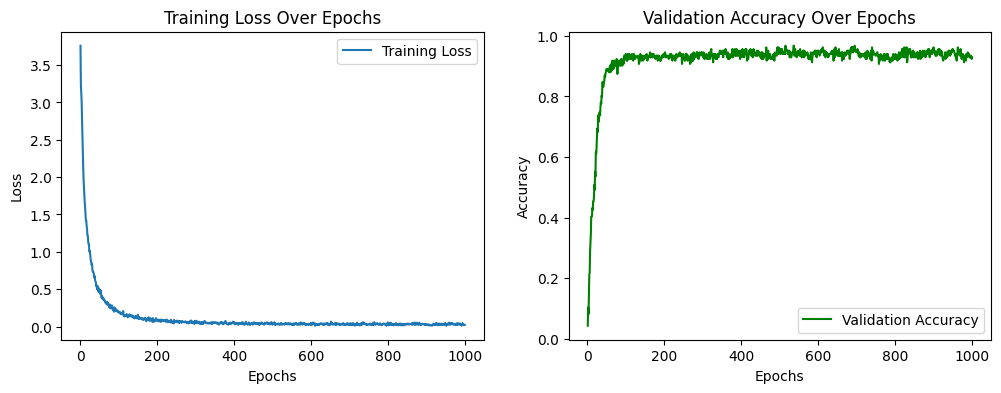

In [ ]:
# Validation set preprocessing
X_valid_preprocessed = preprocess(X_valid2)
one_hot_y_valid = tf.one_hot(y_valid2, 43)

train_losses = []
valid_accuracies = []

with tf.Session() as sess:
    sess.run(tf.global_variables_initializer())
    num_examples = len(y_train2)
    print("Training...")
    print()

    for i in range(EPOCHS):
        normalized_images, y_train2 = shuffle(normalized_images, y_train2)
        epoch_loss = 0  # Για αποθήκευση της απώλειας ανά εποχή

        for offset in range(0, num_examples, BATCH_SIZE):
            end = offset + BATCH_SIZE
            batch_x, batch_y = normalized_images[offset:end], y_train2[offset:end]

            _, batch_loss = sess.run([VGGNet_Model.training_operation, VGGNet_Model.loss_operation],
                feed_dict={x: batch_x, y: batch_y, keep_prob: 0.5, keep_prob_conv: 0.7})

            epoch_loss += batch_loss

        validation_accuracy = VGGNet_Model.evaluate(X_valid_preprocessed, y_valid2)

        train_losses.append(epoch_loss / (num_examples // BATCH_SIZE))  # Μέση απώλεια ανά εποχή
        valid_accuracies.append(validation_accuracy)

        print("EPOCH {} : Loss = {:.4f}, Validation Accuracy = {:.3f}%".format(
            i+1, train_losses[-1], (validation_accuracy*100)))

    VGGNet_Model.saver.save(sess, os.path.join(DIR, model_name))
    print("Model saved")

# Plot training loss and validation accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS+1), train_losses, label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS+1), valid_accuracies, label="Validation Accuracy", color='g')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy Over Epochs")
plt.legend()

plt.show()

In [ ]:
with tf.Session() as sess:
    VGGNet_Model.saver.restore(sess, os.path.join(DIR, "VGGNet"))
    y_pred2 = VGGNet_Model.y_predict(X_test_preprocessed2)
    test_accuracy2 = sum(y_test2 == y_pred2)/len(y_test2)
    print("Test Accuracy for Greek Traffic Signs = {:.1f}%".format(test_accuracy2*100))

Test Accuracy for Greek Traffic Signs = 51.2%


# VIT MODEL

In [ ]:
!pip install accelerate transformers datasets wandb


In [ ]:
import transformers
import random
from PIL import Image, ImageDraw
import pandas as pd
from datasets import Dataset


# -------------------------------------------------

In [ ]:
import pickle
import numpy as np
from datasets import Dataset, DatasetDict
from transformers import AutoImageProcessor

# -----------------------------
#  Load Data from Pickle
# -----------------------------
def load_pickle_data(path):
    with open(path, 'rb') as f:
        data = pickle.load(f)
    X = data['features']
    y = data['labels']
    return X, y

X_train, y_train = load_pickle_data('./train.p')
X_valid, y_valid = load_pickle_data('./valid.p')
X_test, y_test   = load_pickle_data('./test.p')

# -----------------------------
#  Create Hugging Face Datasets
# -----------------------------
from datasets import Dataset, DatasetDict
from transformers import AutoImageProcessor


In [ ]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 2.1 MB/s eta 0:00:00


In [ ]:
from transformers import ViTForImageClassification, TrainingArguments, Trainer
import evaluate
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


# Model
model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=43,
    ignore_mismatched_sizes=True,

)

# Metrics
accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    labels = p.label_ids
    acc = accuracy.compute(predictions=preds, references=labels)
    f1_score = f1.compute(predictions=preds, references=labels, average="weighted")
    return {"accuracy": acc["accuracy"], "f1": f1_score["f1"]}


# TrainingArguments
training_args = TrainingArguments(
    output_dir="./vit-results",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=3,
    learning_rate=2e-4,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=10,
    report_to="none",
    save_total_limit=2,
)


# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    tokenizer=processor,
    compute_metrics=compute_metrics,
)


# Training

trainer.train()


# Evaluation
results = trainer.evaluate(dataset["test"])
print("📊 Test set results:")
print(pd.DataFrame([results]))


# Plot Logs
logs = trainer.state.log_history

# Κρατάμε logs μόνο με loss & accuracy
train_loss = [x["loss"] for x in logs if "loss" in x]
eval_loss = [x["eval_loss"] for x in logs if "eval_loss" in x]
eval_acc  = [x["eval_accuracy"] for x in logs if "eval_accuracy" in x]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, label="Train Loss")
plt.plot(eval_loss, label="Validation Loss")
plt.title("Loss")
plt.xlabel("Steps")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(eval_acc, label="Validation Accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(10, 4))

plt.plot(eval_loss, marker='o', color='orange', label="Validation Loss")
plt.title("Validation Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

# Ελληνικά σήματα οδικής κυκλοφορίας με ViT χωρίς προεκπαίδευση με κάποιο μεγάλο σύνολο δεδομένων


In [ ]:
from transformers import ViTConfig, ViTForImageClassification

#  Νέα ρύθμιση μοντέλου (χωρίς pretraining)
config = ViTConfig(
    image_size=224,
    patch_size=4,
    num_channels=3,
    num_labels=len(set(y_train)),  # 43 για GTSRB ή GreekTSRB
    hidden_size=768,
    num_hidden_layers=12,
    num_attention_heads=12,
    intermediate_size=3072,
)

# Δημιουργία μοντέλου από το μηδέν
model = ViTForImageClassification(config)


In [ ]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from datasets import Dataset, DatasetDict
from transformers import AutoImageProcessor, ViTForImageClassification, TrainingArguments, Trainer, EarlyStoppingCallback
import evaluate
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import seaborn as sns

# -----------------------------
# Load Greek Datasets
# -----------------------------
training_file2 = "/content/Gr_train"
validation_file2 = "/content/Gr_valid"
testing_file2 = "/content/Gr_test.p"

with open(training_file2, mode='rb') as f:
    train2 = pickle.load(f)
with open(validation_file2, mode='rb') as f:
    valid2 = pickle.load(f)
with open(testing_file2, mode='rb') as f:
    test2 = pickle.load(f)

X_train, y_train = train2["data"], train2["label"]
X_valid, y_valid = valid2["data"], valid2["label"]
X_test, y_test = test2["data"], test2["label"]


Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


Map:   0%|          | 0/1536 [00:00<?, ? examples/s]

Map:   0%|          | 0/183 [00:00<?, ? examples/s]

Map:   0%|          | 0/506 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-10-a94aa92033a3>:93: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,2.578600,3.299858,0.202186,0.101262
2,2.827600,3.140543,0.174863,0.105498
3,2.416100,3.046674,0.191257,0.101395


📊 Test set results:
   eval_loss  eval_accuracy   eval_f1  eval_runtime  eval_samples_per_second  \
0   3.631248       0.209486  0.196986       10.4449                   48.445   

   eval_steps_per_second  epoch  
0                  6.127    3.0  


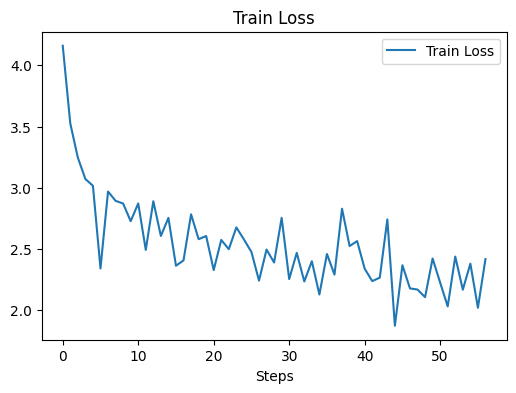

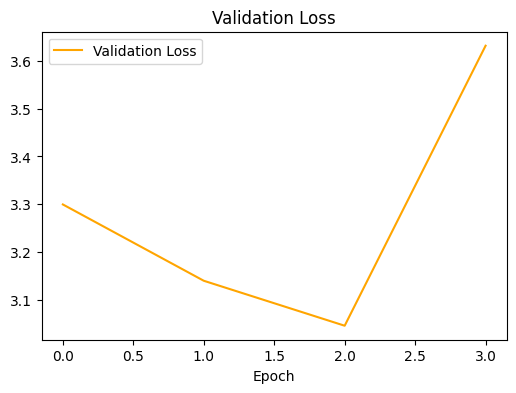

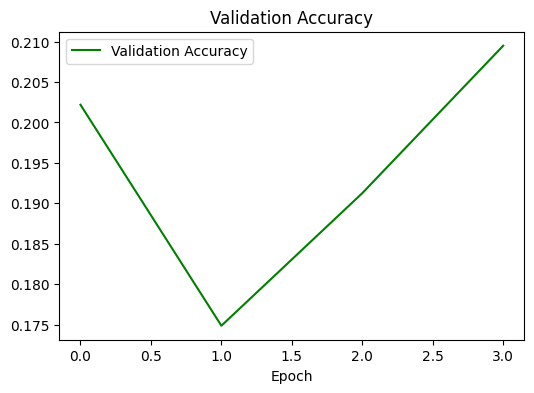

In [ ]:

# -----------------------------
# Convert to HF Datasets
# -----------------------------
def make_dataset(X, y):
    return Dataset.from_list([{"image": x, "label": int(y_)} for x, y_ in zip(X, y)])

train_dataset = make_dataset(X_train, y_train).shuffle(seed=42)
valid_dataset = make_dataset(X_valid, y_valid)
test_dataset  = make_dataset(X_test, y_test)

dataset = DatasetDict({
    "train": train_dataset,
    "validation": valid_dataset,
    "test": test_dataset
})

# -----------------------------
# Image Processor
# -----------------------------
processor = AutoImageProcessor.from_pretrained("google/vit-base-patch16-224")

def transform(example):
    image = np.array(example["image"])
    inputs = processor(image, return_tensors="pt")
    example["pixel_values"] = inputs["pixel_values"][0]
    return example

for split in dataset:
    dataset[split] = dataset[split].map(transform)

# -----------------------------
# Rename + Set Format
# -----------------------------
for split in dataset:
    dataset[split] = dataset[split].rename_column("label", "labels")
    dataset[split].set_format(type="torch", columns=["pixel_values", "labels"])

# -----------------------------
# Initialize New Transformer (No Pretraining)
# -----------------------------
from transformers import ViTConfig, ViTForImageClassification

config = ViTConfig(
    image_size=224,
    patch_size=16,
    num_channels=3,
    num_labels=len(set(y_train)),
    hidden_size=768,
    num_hidden_layers=12,
    num_attention_heads=12,
    intermediate_size=3072,
)

model = ViTForImageClassification(config)



# -----------------------------
# Metrics
# -----------------------------
accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    labels = p.label_ids
    acc = accuracy.compute(predictions=preds, references=labels)
    f1_score = f1.compute(predictions=preds, references=labels, average="weighted")
    return {"accuracy": acc["accuracy"], "f1": f1_score["f1"]}

# -----------------------------
# TrainingArguments
# -----------------------------
training_args = TrainingArguments(
    output_dir="./vit-gr-results",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=10,
    learning_rate=2e-4,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=10,
    report_to="none",
    save_total_limit=2,
    seed=42,
)

# -----------------------------
# Trainer with EarlyStopping
# -----------------------------
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    tokenizer=processor,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

# -----------------------------
#  Train
# -----------------------------
trainer.train()

# -----------------------------
# Evaluate on Test Set
# -----------------------------
results = trainer.evaluate(dataset["test"])
print("📊 Test set results:")
print(pd.DataFrame([results]))

# -----------------------------
# Plot Losses & Accuracy
# -----------------------------
logs = trainer.state.log_history

train_loss = [x["loss"] for x in logs if "loss" in x]
eval_loss = [x["eval_loss"] for x in logs if "eval_loss" in x]
eval_acc  = [x["eval_accuracy"] for x in logs if "eval_accuracy" in x]

# Ξεχωριστά plots για καθαρότητα
plt.figure(figsize=(6, 4))
plt.plot(train_loss, label="Train Loss")
plt.title("Train Loss")
plt.xlabel("Steps")
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(eval_loss, label="Validation Loss", color="orange")
plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(eval_acc, label="Validation Accuracy", color="green")
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.legend()
plt.show()

# -----------------------------
# Confusion Matrix
# -----------------------------
predictions = trainer.predict(dataset["test"])
y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

# Εκπαίδευση ViT με προεκπαιδευμένο μοντέλο στο ImageNet

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


Map:   0%|          | 0/1536 [00:00<?, ? examples/s]

...

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([43]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([43, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-3-89e6d847013b>:111: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.449400,0.729675,0.819672,0.792011
2,0.469500,0.421216,0.890710,0.870574
3,0.113500,0.244596,0.934426,0.931796
4,0.073800,0.117391,0.972678,0.972894
5,0.000700,0.019721,0.989071,0.988904
6,0.000400,0.018223,0.994536,0.994449
7,0.000300,0.017467,0.994536,0.994449
8,0.000300,0.016905,0.994536,0.994449


📊 Test set results:
   eval_loss  eval_accuracy   eval_f1  eval_runtime  eval_samples_per_second  \
0   0.204805       0.956522  0.955609       10.4237                   48.543   

   eval_steps_per_second  epoch  
0                   6.14    8.0  


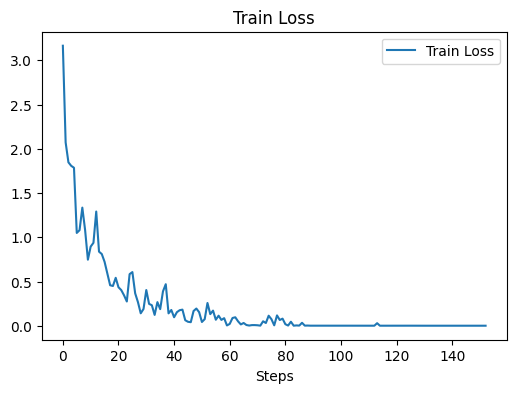

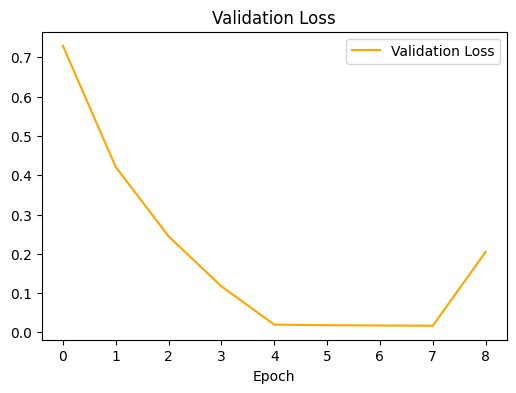

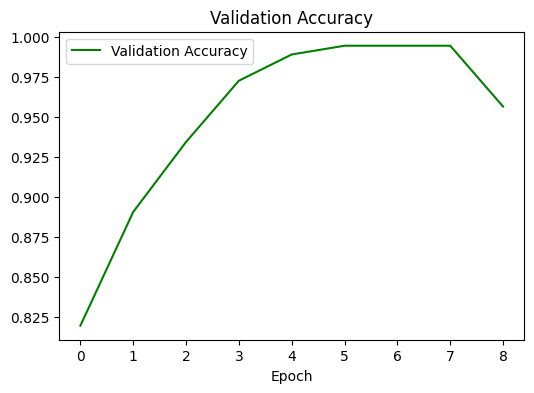

In [ ]:
# Convert to HF Datasets

def make_dataset(X, y):
    return Dataset.from_list([{"image": x, "label": int(y_)} for x, y_ in zip(X, y)])

train_dataset = make_dataset(X_train, y_train).shuffle(seed=42)
valid_dataset = make_dataset(X_valid, y_valid)
test_dataset  = make_dataset(X_test, y_test)

dataset = DatasetDict({
    "train": train_dataset,
    "validation": valid_dataset,
    "test": test_dataset
})


# Image Processor

processor = AutoImageProcessor.from_pretrained("google/vit-base-patch16-224")

def transform(example):
    image = np.array(example["image"])
    inputs = processor(image, return_tensors="pt")
    example["pixel_values"] = inputs["pixel_values"][0]
    return example

for split in dataset:
    dataset[split] = dataset[split].map(transform)


# Rename + Set Format

for split in dataset:
    dataset[split] = dataset[split].rename_column("label", "labels")
    dataset[split].set_format(type="torch", columns=["pixel_values", "labels"])


# Load Model

model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=len(set(y_train)),
    ignore_mismatched_sizes=True,
)


# Metrics

accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    labels = p.label_ids
    acc = accuracy.compute(predictions=preds, references=labels)
    f1_score = f1.compute(predictions=preds, references=labels, average="weighted")
    return {"accuracy": acc["accuracy"], "f1": f1_score["f1"]}


# TrainingArguments

training_args = TrainingArguments(
    output_dir="./vit-gr-results",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=10,
    learning_rate=2e-4,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=10,
    report_to="none",
    save_total_limit=2,
    seed=42,
)


# Trainer with EarlyStopping

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    tokenizer=processor,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)


#  Train

trainer.train()

# Evaluate on Test Set

results = trainer.evaluate(dataset["test"])
print("📊 Test set results:")
print(pd.DataFrame([results]))


# Plot Losses & Accuracy

logs = trainer.state.log_history

train_loss = [x["loss"] for x in logs if "loss" in x]
eval_loss = [x["eval_loss"] for x in logs if "eval_loss" in x]
eval_acc  = [x["eval_accuracy"] for x in logs if "eval_accuracy" in x]

# Ξεχωριστά plots
plt.figure(figsize=(6, 4))
plt.plot(train_loss, label="Train Loss")
plt.title("Train Loss")
plt.xlabel("Steps")
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(eval_loss, label="Validation Loss", color="orange")
plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(eval_acc, label="Validation Accuracy", color="green")
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.legend()
plt.show()


# Confusion Matrix

predictions = trainer.predict(dataset["test"])
y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)


**Παρατηρούμε ότι το προεκπαιδευμένο μοντέλο στο ImageNet μαζί με τα σήματα Ελληνικού οδικού δικτύου έφερε τα καλύτερα αποτελέσματα. Στην περίπτωση χωρίς προεκπαίδευση μόνο με τα Ελληνικά σήματα δεν αποδίδει καλά.**

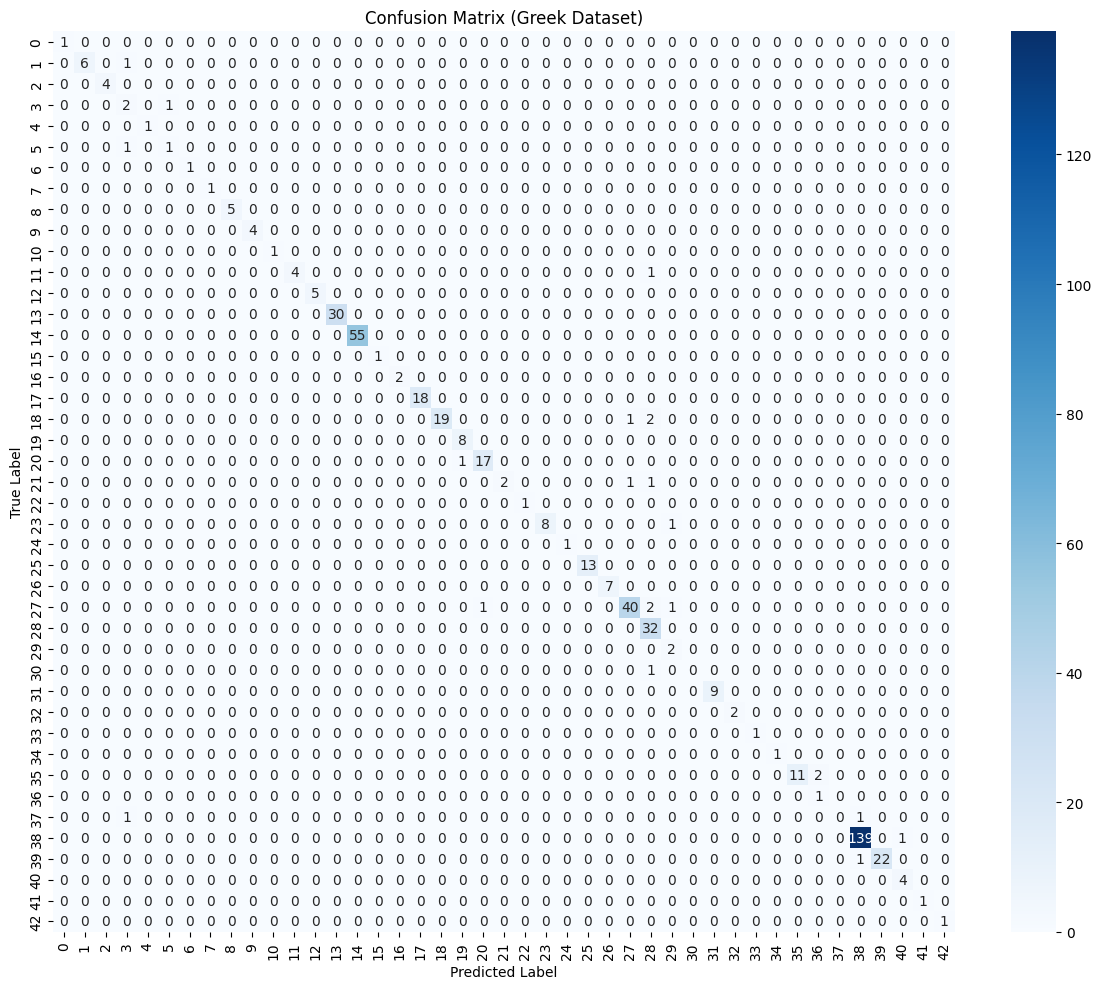

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

# Υπολογισμός confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Αν υπάρχουν 43 classes (όπως στο GTSRB), μπορείς να βάλεις:
labels = [str(i) for i in range(len(np.unique(y_true)))]

# Δημιουργία heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, cbar=True)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Greek Dataset)")
plt.tight_layout()
plt.show()


# Ελεγχο των δεδομένων

In [ ]:
def list_images(dataset, dataset_y, ylabel="", cmap=None):
    """
    Display a list of images in a single figure with matplotlib.
        Parameters:
            images: An np.array compatible with plt.imshow.
            lanel (Default = No label): A string to be used as a label for each image.
            cmap (Default = None): Used to display gray images.
    """
    plt.figure(figsize=(15, 16))
    for i in range(6):
        plt.subplot(1, 6, i+1)
        indx = random.randint(0, len(dataset))
        #Use gray scale color map if there is only one channel
        cmap = 'gray' if len(dataset[indx].shape) == 2 else cmap
        plt.imshow(dataset[indx], cmap = cmap)
        plt.xlabel(signs[dataset_y[indx]])
        plt.ylabel(ylabel)
        plt.xticks([])
        plt.yticks([])
    plt.tight_layout(pad=0, h_pad=0, w_pad=0)
    plt.show()

In [ ]:
def histogram_plot(dataset, label):
    """
    Plots a histogram of the input data.
        Parameters:
            dataset: Input data to be plotted as a histogram.
            lanel: A string to be used as a label for the histogram.
    """
    hist, bins = np.histogram(dataset, bins=n_classes)
    width = 0.7 * (bins[1] - bins[0])
    center = (bins[:-1] + bins[1:]) / 2
    plt.bar(center, hist, align='center', width=width)
    plt.xlabel(label)
    plt.ylabel("Image count")
    plt.show()

In [ ]:
# How many unique classes/labels there are in the dataset.
n_classes = len(np.unique(y_train))

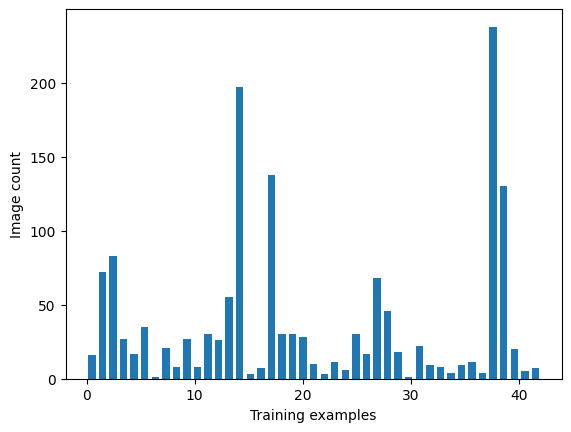

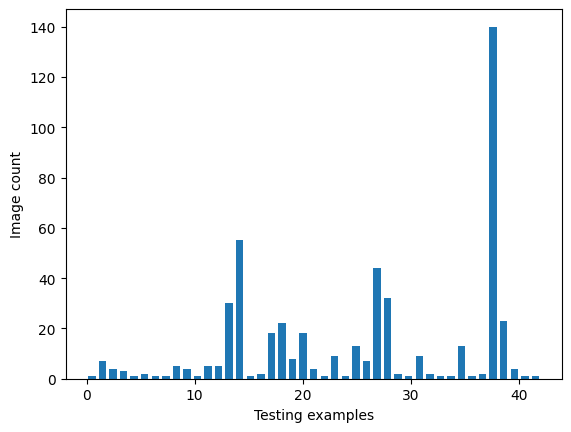

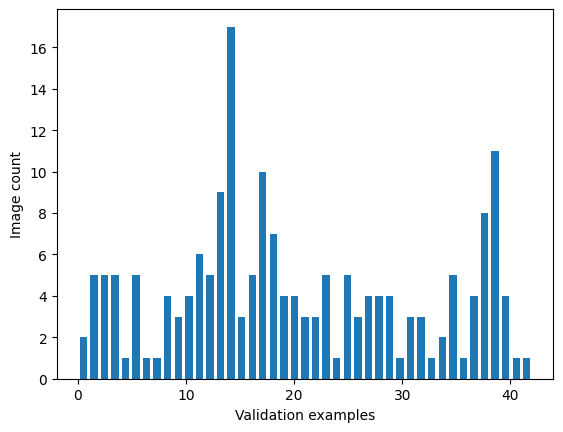

In [ ]:
# Plotting histograms of the count of each sign
histogram_plot(y_train, "Training examples")
histogram_plot(y_test, "Testing examples")
histogram_plot(y_valid, "Validation examples")

#Εκπαίδευση με ResNet στο Ελληνικό dataset

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt


In [ ]:
from torch.utils.data import Dataset
from PIL import Image
import numpy as np
import torch

class TrafficSignDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx]

        # Αν είναι numpy array, κάνε convert σε PIL
        if isinstance(image, np.ndarray):
            if image.dtype != np.uint8:
                image = (image * 255).astype(np.uint8)  # Optional scale-up
            image = Image.fromarray(image)

        # Αν είναι Tensor (π.χ. torch.from_numpy), κάνε επίσης convert
        elif torch.is_tensor(image):
            image = image.numpy()
            if image.dtype != np.uint8:
                image = (image * 255).astype(np.uint8)
            image = Image.fromarray(image)

        # Apply transforms
        if self.transform:
            image = self.transform(image)

        label = int(self.y[idx])  # just in case
        return image, label



In [ ]:
from PIL import Image
import numpy as np
import torch

class TrafficSignDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx]

        # Αν είναι Tensor -> σε numpy
        if torch.is_tensor(image):
            image = image.numpy()

        # Αν είναι float (0–1), scale up
        if isinstance(image, np.ndarray):
            if np.issubdtype(image.dtype, np.floating):
                image = (image * 255).clip(0, 255).astype(np.uint8)
            elif image.dtype != np.uint8:
                # Αν έχει περίεργες int τιμές (π.χ. 9690), κάνε clip
                image = np.clip(image, 0, 255).astype(np.uint8)

            image = Image.fromarray(image)

        if self.transform:
            image = self.transform(image)

        label = int(self.y[idx])
        return image, label


In [ ]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])


In [ ]:
train_ds = TrafficSignDataset(X_train, y_train, transform=transform)
valid_ds = TrafficSignDataset(X_valid, y_valid, transform=transform)
test_ds  = TrafficSignDataset(X_test,  y_test,  transform=transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, len(set(y_train)))  # output layer
model = model.to(device)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-5)


In [ ]:
def train(model, train_loader, valid_loader, epochs):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    train_losses, val_losses, val_accuracies = [], [], []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device).long()  # 🔧 Σωστό dtype
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        train_losses.append(total_loss / len(train_loader))

        # --- Validation ---
        model.eval()
        val_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in valid_loader:
                inputs, labels = inputs.to(device), labels.to(device).long()  # 🔧 Εδώ γίνεται συχνά το λάθος!
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_losses.append(val_loss / len(valid_loader))
        val_accuracies.append(correct / total)

        print(f"Epoch {epoch+1}/{epochs}: "
              f"Train Loss: {train_losses[-1]:.4f}, "
              f"Val Loss: {val_losses[-1]:.4f}, "
              f"Val Acc: {val_accuracies[-1]:.4f}")

    return train_losses, val_losses, val_accuracies



In [ ]:
train_losses, val_losses, val_accuracies = train(model, train_loader, valid_loader, epochs=40)


Epoch 1/40: Train Loss: 2.9012, Val Loss: 3.5904, Val Acc: 0.1257
Epoch 2/40: Train Loss: 2.2392, Val Loss: 3.2221, Val Acc: 0.2514
Epoch 3/40: Train Loss: 1.9795, Val Loss: 2.6771, Val Acc: 0.2842
Epoch 4/40: Train Loss: 1.7476, Val Loss: 2.5010, Val Acc: 0.2951
Epoch 5/40: Train Loss: 1.6057, Val Loss: 2.5345, Val Acc: 0.2732
Epoch 6/40: Train Loss: 1.5345, Val Loss: 2.1958, Val Acc: 0.3607
Epoch 7/40: Train Loss: 1.4142, Val Loss: 2.2918, Val Acc: 0.3497
Epoch 8/40: Train Loss: 1.3051, Val Loss: 2.0922, Val Acc: 0.3934
Epoch 9/40: Train Loss: 1.2213, Val Loss: 1.8648, Val Acc: 0.3607
Epoch 10/40: Train Loss: 1.1560, Val Loss: 1.8040, Val Acc: 0.4098
Epoch 11/40: Train Loss: 1.1205, Val Loss: 1.8575, Val Acc: 0.4590
Epoch 12/40: Train Loss: 1.0254, Val Loss: 1.9499, Val Acc: 0.4153
Epoch 13/40: Train Loss: 0.9157, Val Loss: 1.7113, Val Acc: 0.4809
Epoch 14/40: Train Loss: 0.8328, Val Loss: 1.7040, Val Acc: 0.4918
Epoch 15/40: Train Loss: 0.7524, Val Loss: 1.7763, Val Acc: 0.4699
Epoc

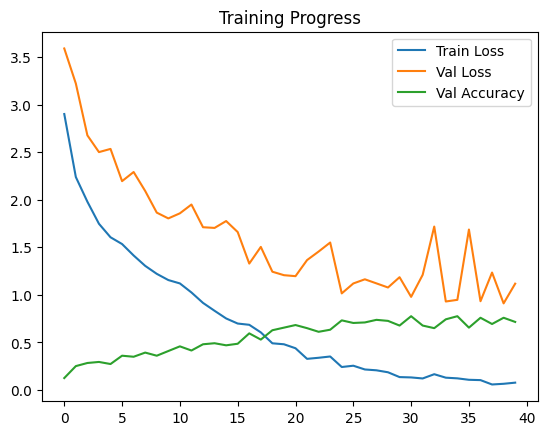

In [ ]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.plot(val_accuracies, label="Val Accuracy")
plt.legend()
plt.title("Training Progress")
plt.show()

In [ ]:
def evaluate(model, test_loader):
    model.eval()
    correct = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            correct += (preds == labels).sum().item()

    acc = correct / len(test_loader.dataset)
    print(f"📊 Test Accuracy: {acc:.4f}")
    return all_preds, all_labels

preds, labels = evaluate(model, test_loader)


📊 Test Accuracy: 0.2589


# Hybrid CNN + ViT

In [ ]:
def preprocess_data(X, y):
    # Βεβαιώνεται ότι κάθε εικόνα είναι σωστός πίνακας (np.ndarray με dtype uint8)
    if isinstance(X, np.ndarray) and X.dtype == 'O':
        X = np.array([np.array(img, dtype=np.uint8) for img in X])

    images = torch.stack([transform(img) for img in X])
    labels = torch.tensor(y)
    return {"pixel_values": images, "labels": labels}



In [ ]:
print("X_train shape:", X_train.shape, "dtype:", X_train.dtype)
print("X_test shape:", X_test.shape, "dtype:", X_test.dtype)


X_train shape: (1536, 32, 32, 3) dtype: uint8
X_test shape: (506, 32, 32, 3) dtype: object


In [ ]:
if isinstance(X_test, np.ndarray) and X_test.dtype == 'O':
    X_test = np.array([np.array(img, dtype=np.uint8) for img in X_test])


In [ ]:
import torchvision.transforms as T

transform = T.Compose([
    T.ToTensor(),  # μετατρέπει εικόνα [H, W, C] -> [C, H, W] και float32 [0,1]
])


In [ ]:
train_dict = preprocess_data(X_train, y_train)
val_dict   = preprocess_data(X_valid, y_valid)
test_dict  = preprocess_data(X_test, y_test)


In [ ]:
!pip install datasets

In [ ]:
import torch
from torchvision import transforms
from datasets import Dataset, DatasetDict
transform = transforms.Compose([
    transforms.ToTensor(),  # μετατροπή σε [0,1] και (C, H, W)
])

def preprocess_data(X, y):
    images = torch.stack([transform(img) for img in X])
    labels = torch.tensor(y)
    return {"pixel_values": images, "labels": labels}



dataset = DatasetDict({
    "train": Dataset.from_dict(train_dict),
    "validation": Dataset.from_dict(val_dict),
    "test": Dataset.from_dict(test_dict),
})


In [ ]:
import torchvision.models as models
import torch.nn as nn

class VGG_FeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg16(pretrained=True)
        self.features = vgg.features  # Όλο το VGG χωρίς τα fully connected
        self.pool = nn.AdaptiveAvgPool2d((8, 8))  # Για να έχει ίδια μορφή

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)  # σχήμα: (B, C=512, H=8, W=8)
        return x


In [ ]:
class Hybrid_VGG_ViT(nn.Module):
    def __init__(self, vit_model_name="google/vit-base-patch16-224", num_classes=43):
        super().__init__()
        self.vgg = VGG_FeatureExtractor()
        self.patch_embed = nn.Conv2d(512, 768, kernel_size=1)  # προσαρμογή για transformer
        self.vit = ViTForImageClassification.from_pretrained(
            vit_model_name,
            num_labels=num_classes,
            ignore_mismatched_sizes=True,
        )

    def forward(self, x, labels=None):
        with torch.no_grad():
            x = self.vgg(x)  # shape: (B, 512, 8, 8)
        x = self.patch_embed(x)  # shape: (B, 768, 8, 8)
        x = x.flatten(2).transpose(1, 2)  # shape: (B, 64, 768)

        # ViT expects dict with pixel_values or inputs_embeds
        outputs = self.vit(inputs_embeds=x, labels=labels)
        return outputs


In [ ]:
!pip install torchvision


In [ ]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from tqdm import tqdm

# Προετοιμασία του VGG16
vgg = models.vgg16(pretrained=True).features.eval().cuda()

# Μετατροπή εικόνων σε torch tensors και resize για VGG
preprocess = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

def extract_features(images_np):
    features = []
    for img in tqdm(images_np):
        img_tensor = preprocess(img).unsqueeze(0).cuda()  # (1, 3, 224, 224)
        with torch.no_grad():
            feat = vgg(img_tensor)
        features.append(feat.squeeze().cpu().numpy())
    return np.array(features)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
# Αν μετατρέψουμε τις εικόνες σε σωστό format
def fix_images(X):
    if X.dtype != np.uint8:
        fixed = []
        for img in X:
            img_fixed = np.array(img, dtype=np.uint8)
            fixed.append(img_fixed)
        return np.stack(fixed)
    return X

# Καθαρισμένα σύνολα
X_train_clean = fix_images(X_train)
X_valid_clean = fix_images(X_valid)
X_test_clean = fix_images(X_test)
